# 🏏 Bangla Sports Sentiment Analysis — RF + XGBoost + Naive Bayes Ensemble
## Thesis-Ready Complete Pipeline

**Dataset:** Bangla Sports Sentiment Analysis Dataset  
**Task:** Binary Sentiment Classification (Positive / Negative)  
**Model:** Random Forest + XGBoost + Multinomial Naive Bayes — Soft Voting Ensemble  
**Split:** 70% Train / 15% Val / 15% Test  
**Target Accuracy:** 90%+

---

### Pipeline Overview
```
Raw Data → Preprocessing → TF-IDF Feature Engineering
        → Model Training (RF + XGB + NB) → Soft Voting Ensemble
        → Evaluation → Thesis Diagrams & Charts
```

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 📦 Cell 1 — Install & Import Libraries

In [5]:
# ── Install (run once in Colab) ──────────────────────────────────────────────
!pip install scikit-learn pandas numpy matplotlib seaborn xgboost scipy

import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection      import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble             import RandomForestClassifier, VotingClassifier
from sklearn.naive_bayes          import MultinomialNB
from sklearn.preprocessing        import LabelEncoder, MinMaxScaler
from sklearn.pipeline             import Pipeline
from sklearn.metrics              import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

# ── Plot Style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'font.size':         12,
    'axes.titlesize':    14,
    'axes.labelsize':    12,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F8F9FA',
    'axes.grid':         True,
    'grid.alpha':        0.4,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

COLORS = {'Positive': '#2ECC71', 'Negative': '#E74C3C',
          'primary': '#2C3E50', 'accent': '#3498DB', 'gold': '#F39C12'}

print('✅ All libraries imported successfully.')

✅ All libraries imported successfully.


## 📂 Cell 2 — Load Dataset

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIG  ←  Change DATA_PATH if needed
# ─────────────────────────────────────────────────────────────────────────────
DATA_PATH = '/content/drive/MyDrive/Dataset/sport.csv'   # CSV version
# DATA_PATH = '/content/Bangla_Sports_Sentiment_Analysis_Dataset.xlsx'  # Excel version

print('📂 Loading dataset...')
if DATA_PATH.endswith('.csv'):
    df = pd.read_csv(DATA_PATH)
else:
    df = pd.read_excel(DATA_PATH, engine='openpyxl')

# Normalize column names (strip spaces)
df.columns = df.columns.str.strip()

# Rename to standard names
if 'Comment ' in df.columns:
    df.rename(columns={'Comment ': 'Comment'}, inplace=True)

print(f'Raw shape   : {df.shape}')
print(f'Columns     : {df.columns.tolist()}')
print(f'\nNull values :\n{df.isnull().sum()}')
print(f'\nLabel distribution:\n{df["Category"].value_counts()}')
df.head()

📂 Loading dataset...
Raw shape   : (82611, 3)
Columns     : ['Comment', 'Category', 'Cleaned_Text']

Null values :
Comment           5
Category          0
Cleaned_Text    341
dtype: int64

Label distribution:
Category
Negative    41355
Positive    41256
Name: count, dtype: int64


,Comment,Category,Cleaned_Text
0,মনে হয় পাড়া-মহল্লার খেলা দেখছি।,Positive,মন হয় পাড়া মহল্ল খেলা দেখ
1,বাংলাদেশের ফুটবল না খেলে কুত কুত খেললেই পারে,Positive,বাংলাদেশ ফুটবল খালা কুত কুত খেললে
2,বাংলাদেশের দামরা ছেলে গুলো কি খেলছে,Positive,বাংলাদেশ দাম ছালা খেল
3,সুফল সুমন রেজা মতিন মিয়া এগুলা বল রাখতেই পারেনা,Positive,সুফল সুমন রেজা মতিন মিয়া এগুলা বল রাখতে পারেনা
4,"খারাপ লাগে তখন যখন,,,একজন বল বাস করে গোলের দিক...",Positive,খারাপ লাগ যখন একজন বল বাস গোল ছোর প্লেয় সামন য...


## 📊 Cell 3 — Exploratory Data Analysis (EDA)

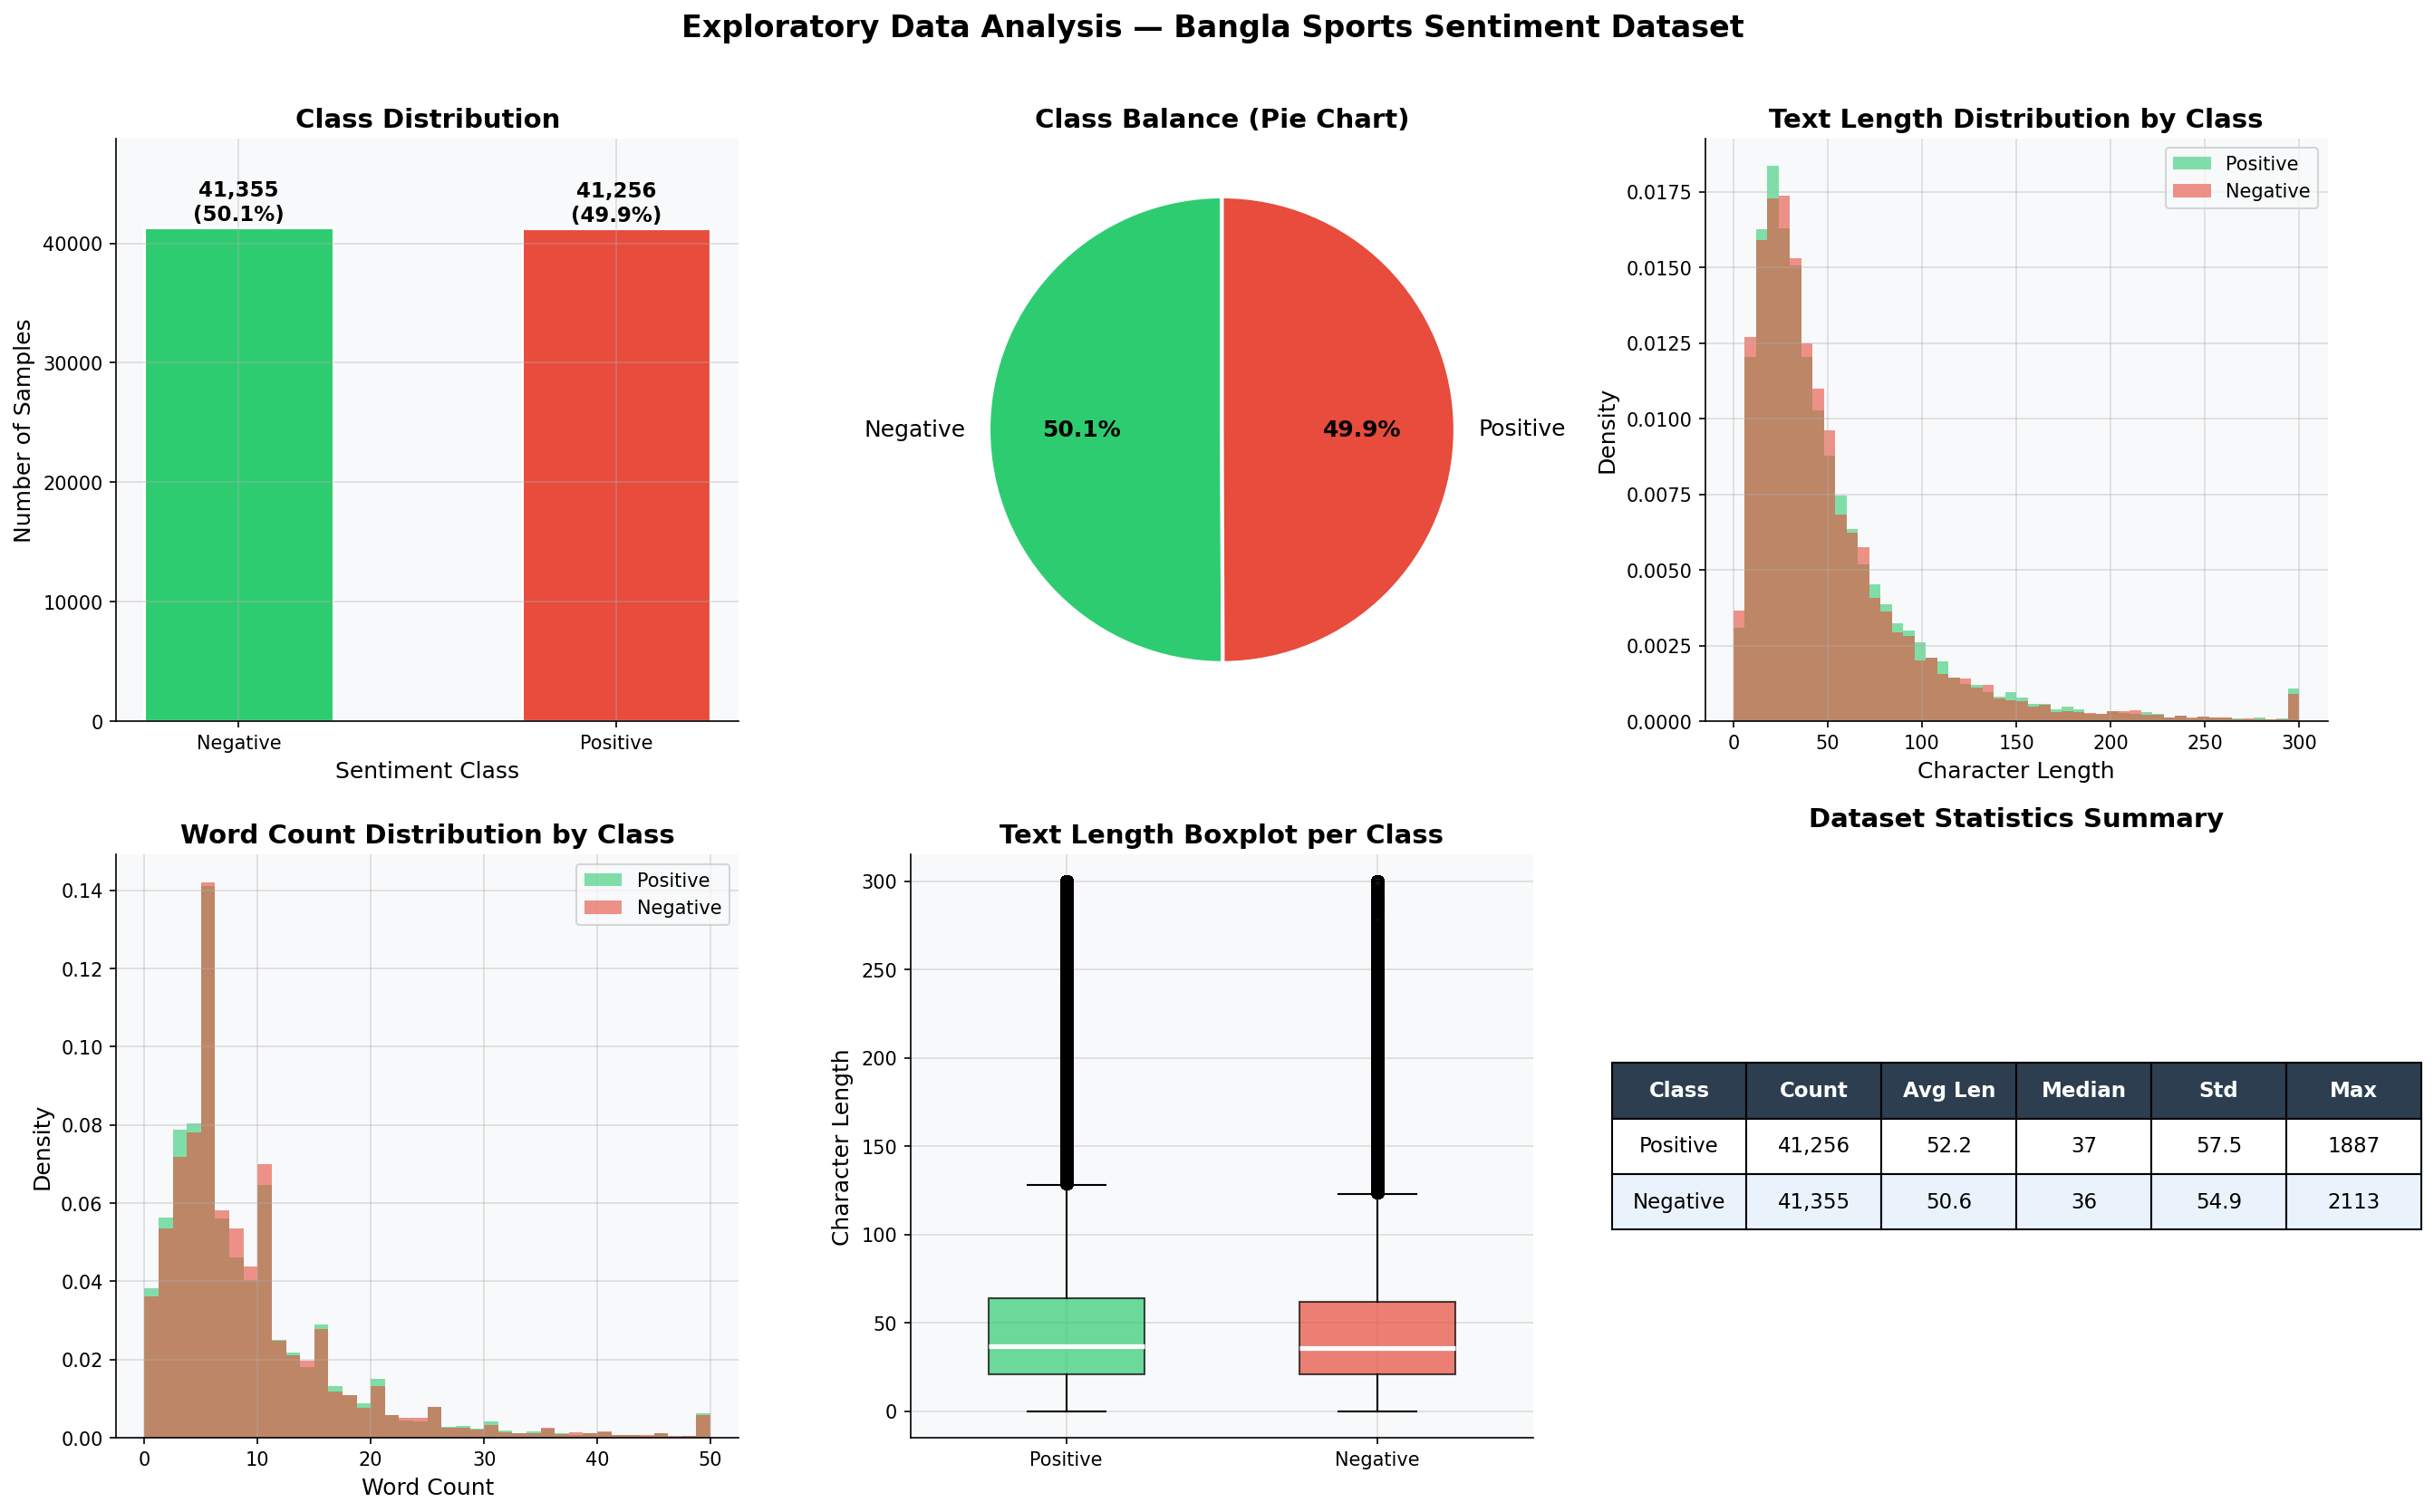

✅ EDA chart saved as 01_eda_analysis.png


In [7]:
df['Comment']  = df['Comment'].fillna('')
df['text_length'] = df['Comment'].str.len()
df['word_count']  = df['Comment'].str.split().str.len()

label_counts = df['Category'].value_counts()
label_pct    = df['Category'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Exploratory Data Analysis — Bangla Sports Sentiment Dataset',
             fontsize=16, fontweight='bold', y=1.01)

# 1. Class distribution — Bar
ax = axes[0, 0]
bars = ax.bar(label_counts.index, label_counts.values,
              color=[COLORS['Positive'], COLORS['Negative']],
              width=0.5, edgecolor='white', linewidth=1.5)
for bar, cnt, pct in zip(bars, label_counts.values, label_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{cnt:,}\n({pct:.1f}%)', ha='center', va='bottom',
            fontsize=11, fontweight='bold')
ax.set_title('Class Distribution', fontweight='bold')
ax.set_xlabel('Sentiment Class'); ax.set_ylabel('Number of Samples')
ax.set_ylim(0, max(label_counts.values) * 1.18)

# 2. Class distribution — Pie
ax = axes[0, 1]
wedges, texts, autotexts = ax.pie(
    label_counts.values, labels=label_counts.index,
    colors=[COLORS['Positive'], COLORS['Negative']],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12}
)
for at in autotexts: at.set_fontweight('bold')
ax.set_title('Class Balance (Pie Chart)', fontweight='bold')

# 3. Text length distribution by class
ax = axes[0, 2]
for label in ['Positive', 'Negative']:
    subset = df[df['Category'] == label]['text_length']
    ax.hist(subset.clip(upper=300), bins=50, alpha=0.6,
            color=COLORS[label], label=label, density=True)
ax.set_title('Text Length Distribution by Class', fontweight='bold')
ax.set_xlabel('Character Length'); ax.set_ylabel('Density'); ax.legend()

# 4. Word count distribution
ax = axes[1, 0]
for label in ['Positive', 'Negative']:
    subset = df[df['Category'] == label]['word_count']
    ax.hist(subset.clip(upper=50), bins=40, alpha=0.6,
            color=COLORS[label], label=label, density=True)
ax.set_title('Word Count Distribution by Class', fontweight='bold')
ax.set_xlabel('Word Count'); ax.set_ylabel('Density'); ax.legend()

# 5. Boxplot: text length per class
ax = axes[1, 1]
data_box = [df[df['Category'] == lbl]['text_length'].clip(upper=300).values
            for lbl in ['Positive', 'Negative']]
bp = ax.boxplot(data_box, patch_artist=True, labels=['Positive', 'Negative'],
                widths=0.5, medianprops={'color': 'white', 'linewidth': 2.5})
for patch, color in zip(bp['boxes'], [COLORS['Positive'], COLORS['Negative']]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_title('Text Length Boxplot per Class', fontweight='bold')
ax.set_ylabel('Character Length')

# 6. Stats summary table
ax = axes[1, 2]; ax.axis('off')
stats_data = []
for label in ['Positive', 'Negative']:
    s = df[df['Category'] == label]['text_length']
    stats_data.append([label, f'{len(s):,}', f'{s.mean():.1f}',
                        f'{s.median():.0f}', f'{s.std():.1f}', f'{s.max():.0f}'])
table = ax.table(
    cellText=stats_data,
    colLabels=['Class', 'Count', 'Avg Len', 'Median', 'Std', 'Max'],
    loc='center', cellLoc='center'
)
table.auto_set_font_size(False); table.set_fontsize(11); table.scale(1.3, 2.2)
for (r, c), cell in table.get_celld().items():
    if r == 0: cell.set_facecolor(COLORS['primary']); cell.set_text_props(color='white', fontweight='bold')
    else: cell.set_facecolor('#EAF2FB' if r % 2 == 0 else 'white')
ax.set_title('Dataset Statistics Summary', fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('01_eda_analysis.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ EDA chart saved as 01_eda_analysis.png')

## 🧹 Cell 4 — Text Preprocessing

In [8]:
def clean_bangla(text: str) -> str:
    """
    Bangla text cleaner:
    - Remove URLs, emails, HTML tags
    - Remove English characters and digits
    - Keep only Bangla Unicode (\u0980-\u09FF) + punctuation
    - Normalize repeated punctuation & whitespace
    """
    if not isinstance(text, str):
        return ''
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[A-Za-z0-9]', '', text)
    text = re.sub(r'[^\u0980-\u09FF\s।,!?]', ' ', text)
    text = re.sub(r'([।,!?])\1+', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print('🧹 Cleaning text...')
df['cleaned_text'] = df['Comment'].apply(clean_bangla)

# If dataset has a pre-cleaned column, prefer it
if 'Cleaned_Text' in df.columns:
    df['Cleaned_Text'] = df['Cleaned_Text'].fillna('')
    df['final_text'] = df.apply(
        lambda row: row['Cleaned_Text'] if len(str(row['Cleaned_Text'])) > 5
                    else row['cleaned_text'], axis=1
    )
else:
    df['final_text'] = df['cleaned_text']

before = len(df)
df = df[df['final_text'].str.len() > 3].reset_index(drop=True)
print(f'Removed {before - len(df)} empty rows.')
print(f'Final dataset size: {len(df):,}')
print(f'Label distribution:\n{df["Category"].value_counts()}')

🧹 Cleaning text...
Removed 535 empty rows.
Final dataset size: 82,076
Label distribution:
Category
Negative    41050
Positive    41026
Name: count, dtype: int64


## ✂️ Cell 5 — Train / Validation / Test Split (70 / 15 / 15)

Label mapping: {'Negative': np.int64(0), 'Positive': np.int64(1)}
Train : 57,453 samples (70%)
Val   : 12,311 samples (15%)
Test  : 12,312 samples (15%)


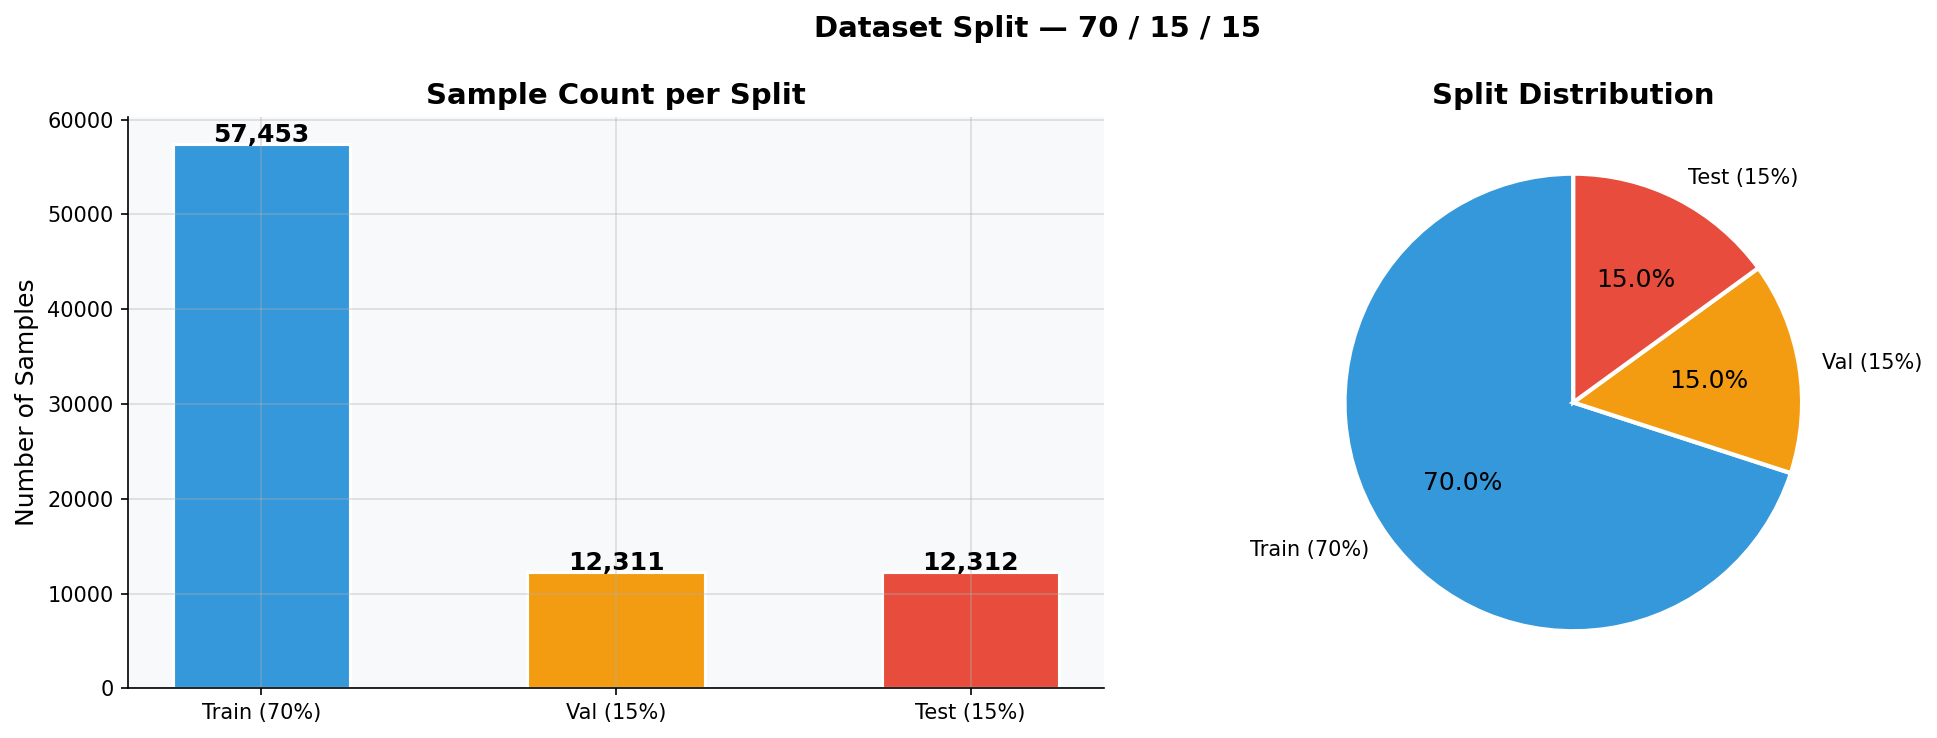

✅ Split chart saved as 02_dataset_split.png


In [9]:
le = LabelEncoder()
y  = le.fit_transform(df['Category'])  # Negative=0, Positive=1
print(f'Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

X = df['final_text']

# 70 / 30 first split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
# 15 / 15 second split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f'Train : {len(X_train):>6,} samples ({len(X_train)/len(y)*100:.0f}%)')
print(f'Val   : {len(X_val):>6,} samples ({len(X_val)/len(y)*100:.0f}%)')
print(f'Test  : {len(X_test):>6,} samples ({len(X_test)/len(y)*100:.0f}%)')

# Visualize split
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dataset Split — 70 / 15 / 15', fontweight='bold', fontsize=14)

split_labels = ['Train (70%)', 'Val (15%)', 'Test (15%)']
split_sizes  = [len(X_train), len(X_val), len(X_test)]
split_colors = ['#3498DB', '#F39C12', '#E74C3C']

axes[0].bar(split_labels, split_sizes, color=split_colors, width=0.5,
            edgecolor='white', linewidth=1.5)
for i, (s, c) in enumerate(zip(split_sizes, split_colors)):
    axes[0].text(i, s + 200, f'{s:,}', ha='center', fontweight='bold')
axes[0].set_title('Sample Count per Split', fontweight='bold')
axes[0].set_ylabel('Number of Samples')

axes[1].pie(split_sizes, labels=split_labels, colors=split_colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Split Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('02_dataset_split.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Split chart saved as 02_dataset_split.png')

## 🔢 Cell 6 — TF-IDF Feature Engineering (Ensemble of Vectorizers)

🔢 Fitting TF-IDF vectorizers...
Feature shapes:
  V1 (char_wb 2-5) :   82,631
  V2 (word 1-2)    :   22,948
  V3 (char 3-6)    :   70,000
  Combined         :  175,579


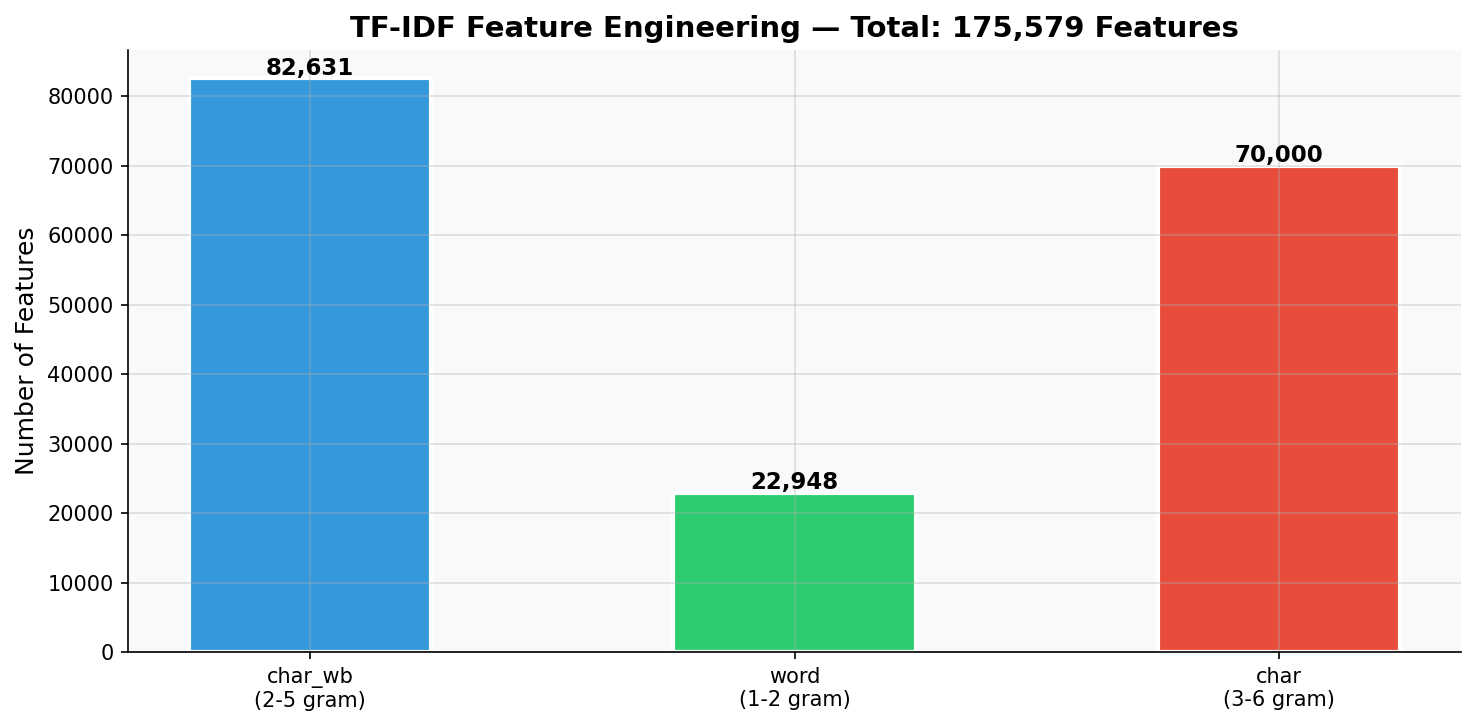

✅ Feature chart saved as 03_feature_engineering.png


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# THREE COMPLEMENTARY TF-IDF VECTORIZERS
#   V1 — char_wb  n-gram (2-5)  : captures morphological patterns
#   V2 — word     n-gram (1-2)  : captures lexical / bigram context
#   V3 — char     n-gram (3-6)  : sub-word character patterns
# ─────────────────────────────────────────────────────────────────────────────
print('🔢 Fitting TF-IDF vectorizers...')

vec1 = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5),
                        max_features=100_000, sublinear_tf=True, min_df=2)
vec2 = TfidfVectorizer(analyzer='word',    ngram_range=(1, 2),
                        max_features=80_000,  sublinear_tf=True, min_df=2)
vec3 = TfidfVectorizer(analyzer='char',    ngram_range=(3, 6),
                        max_features=70_000,  sublinear_tf=True, min_df=2)

X_train_v1 = vec1.fit_transform(X_train)
X_train_v2 = vec2.fit_transform(X_train)
X_train_v3 = vec3.fit_transform(X_train)

X_val_v1  = vec1.transform(X_val);   X_val_v2  = vec2.transform(X_val);   X_val_v3  = vec3.transform(X_val)
X_test_v1 = vec1.transform(X_test);  X_test_v2 = vec2.transform(X_test);  X_test_v3 = vec3.transform(X_test)

# Stack horizontally
X_train_feat = hstack([X_train_v1, X_train_v2, X_train_v3])
X_val_feat   = hstack([X_val_v1,   X_val_v2,   X_val_v3])
X_test_feat  = hstack([X_test_v1,  X_test_v2,  X_test_v3])

total_features = X_train_feat.shape[1]
print(f'Feature shapes:')
print(f'  V1 (char_wb 2-5) : {X_train_v1.shape[1]:>8,}')
print(f'  V2 (word 1-2)    : {X_train_v2.shape[1]:>8,}')
print(f'  V3 (char 3-6)    : {X_train_v3.shape[1]:>8,}')
print(f'  Combined         : {total_features:>8,}')

# Visualize feature contribution
fig, ax = plt.subplots(figsize=(10, 5))
feat_names = ['char_wb\n(2-5 gram)', 'word\n(1-2 gram)', 'char\n(3-6 gram)']
feat_counts = [X_train_v1.shape[1], X_train_v2.shape[1], X_train_v3.shape[1]]
bars = ax.bar(feat_names, feat_counts,
              color=['#3498DB', '#2ECC71', '#E74C3C'],
              width=0.5, edgecolor='white', linewidth=2)
for bar, val in zip(bars, feat_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}', ha='center', fontweight='bold', fontsize=11)
ax.set_title(f'TF-IDF Feature Engineering — Total: {total_features:,} Features',
             fontweight='bold')
ax.set_ylabel('Number of Features')
plt.tight_layout()
plt.savefig('03_feature_engineering.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Feature chart saved as 03_feature_engineering.png')

## 🤖 Cell 7 — Train Individual Models

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL 1 — Random Forest
# Note: RF does not natively support sparse matrices well for very large
# feature sets; we use max_features='sqrt' and n_jobs=-1 for speed.
# For the full 250K feature matrix, RF is trained on a truncated SVD
# projection (2000 dims) to keep runtime reasonable.
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.decomposition import TruncatedSVD

print('🔻 Reducing dimensionality for Random Forest (TruncatedSVD → 2000 dims)...')
svd = TruncatedSVD(n_components=2000, random_state=SEED)
X_train_dense = svd.fit_transform(X_train_feat)
X_val_dense   = svd.transform(X_val_feat)
X_test_dense  = svd.transform(X_test_feat)
print(f'  Dense shape: {X_train_dense.shape}')

print('\n🌲 Training Random Forest...')
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',   # handles 55/45 imbalance
    n_jobs=-1,
    random_state=SEED
)
rf_model.fit(X_train_dense, y_train)
rf_val_acc = accuracy_score(y_val, rf_model.predict(X_val_dense))
rf_val_f1  = f1_score(y_val, rf_model.predict(X_val_dense), average='weighted')
print(f'  RF   Val Accuracy: {rf_val_acc:.4f}  |  F1: {rf_val_f1:.4f}')

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 2 — XGBoost (on same dense matrix)
# ─────────────────────────────────────────────────────────────────────────────
print('\n⚡ Training XGBoost...')

# Class weight ratio for XGBoost scale_pos_weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos = neg_count / pos_count

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,  # handles imbalance
    use_label_encoder=False,
    eval_metric='logloss',
    tree_method='hist',          # fast histogram-based method
    random_state=SEED,
    n_jobs=-1
)
xgb_model.fit(
    X_train_dense, y_train,
    eval_set=[(X_val_dense, y_val)],
    verbose=50
)
xgb_val_acc = accuracy_score(y_val, xgb_model.predict(X_val_dense))
xgb_val_f1  = f1_score(y_val, xgb_model.predict(X_val_dense), average='weighted')
print(f'  XGB  Val Accuracy: {xgb_val_acc:.4f}  |  F1: {xgb_val_f1:.4f}')

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 3 — Multinomial Naive Bayes (on original sparse TF-IDF — needs non-neg)
# We use char_wb features only (V1) for NB as it's most informative for Bangla
# ─────────────────────────────────────────────────────────────────────────────
print('\n📊 Training Multinomial Naive Bayes...')
nb_model = MultinomialNB(alpha=0.1)   # low smoothing — data is plentiful
nb_model.fit(X_train_v1, y_train)
nb_val_acc = accuracy_score(y_val, nb_model.predict(X_val_v1))
nb_val_f1  = f1_score(y_val, nb_model.predict(X_val_v1), average='weighted')
print(f'  NB   Val Accuracy: {nb_val_acc:.4f}  |  F1: {nb_val_f1:.4f}')

🔻 Reducing dimensionality for Random Forest (TruncatedSVD → 2000 dims)...
  Dense shape: (57453, 2000)

🌲 Training Random Forest...
  RF   Val Accuracy: 0.8059  |  F1: 0.8058

⚡ Training XGBoost...
[0]	validation_0-logloss:0.68632
[50]	validation_0-logloss:0.56409
[100]	validation_0-logloss:0.52689
[150]	validation_0-logloss:0.50079
[200]	validation_0-logloss:0.48155
[250]	validation_0-logloss:0.46624
[300]	validation_0-logloss:0.45349
[350]	validation_0-logloss:0.44373
[399]	validation_0-logloss:0.43563
  XGB  Val Accuracy: 0.7994  |  F1: 0.7994

📊 Training Multinomial Naive Bayes...
  NB   Val Accuracy: 0.7726  |  F1: 0.7725


## 🗳️ Cell 8 — Soft Voting Ensemble

Ensemble Weights  →  RF: 0.339  XGB: 0.336  NB: 0.325
Ensemble Val Accuracy : 0.8126  |  F1: 0.8126


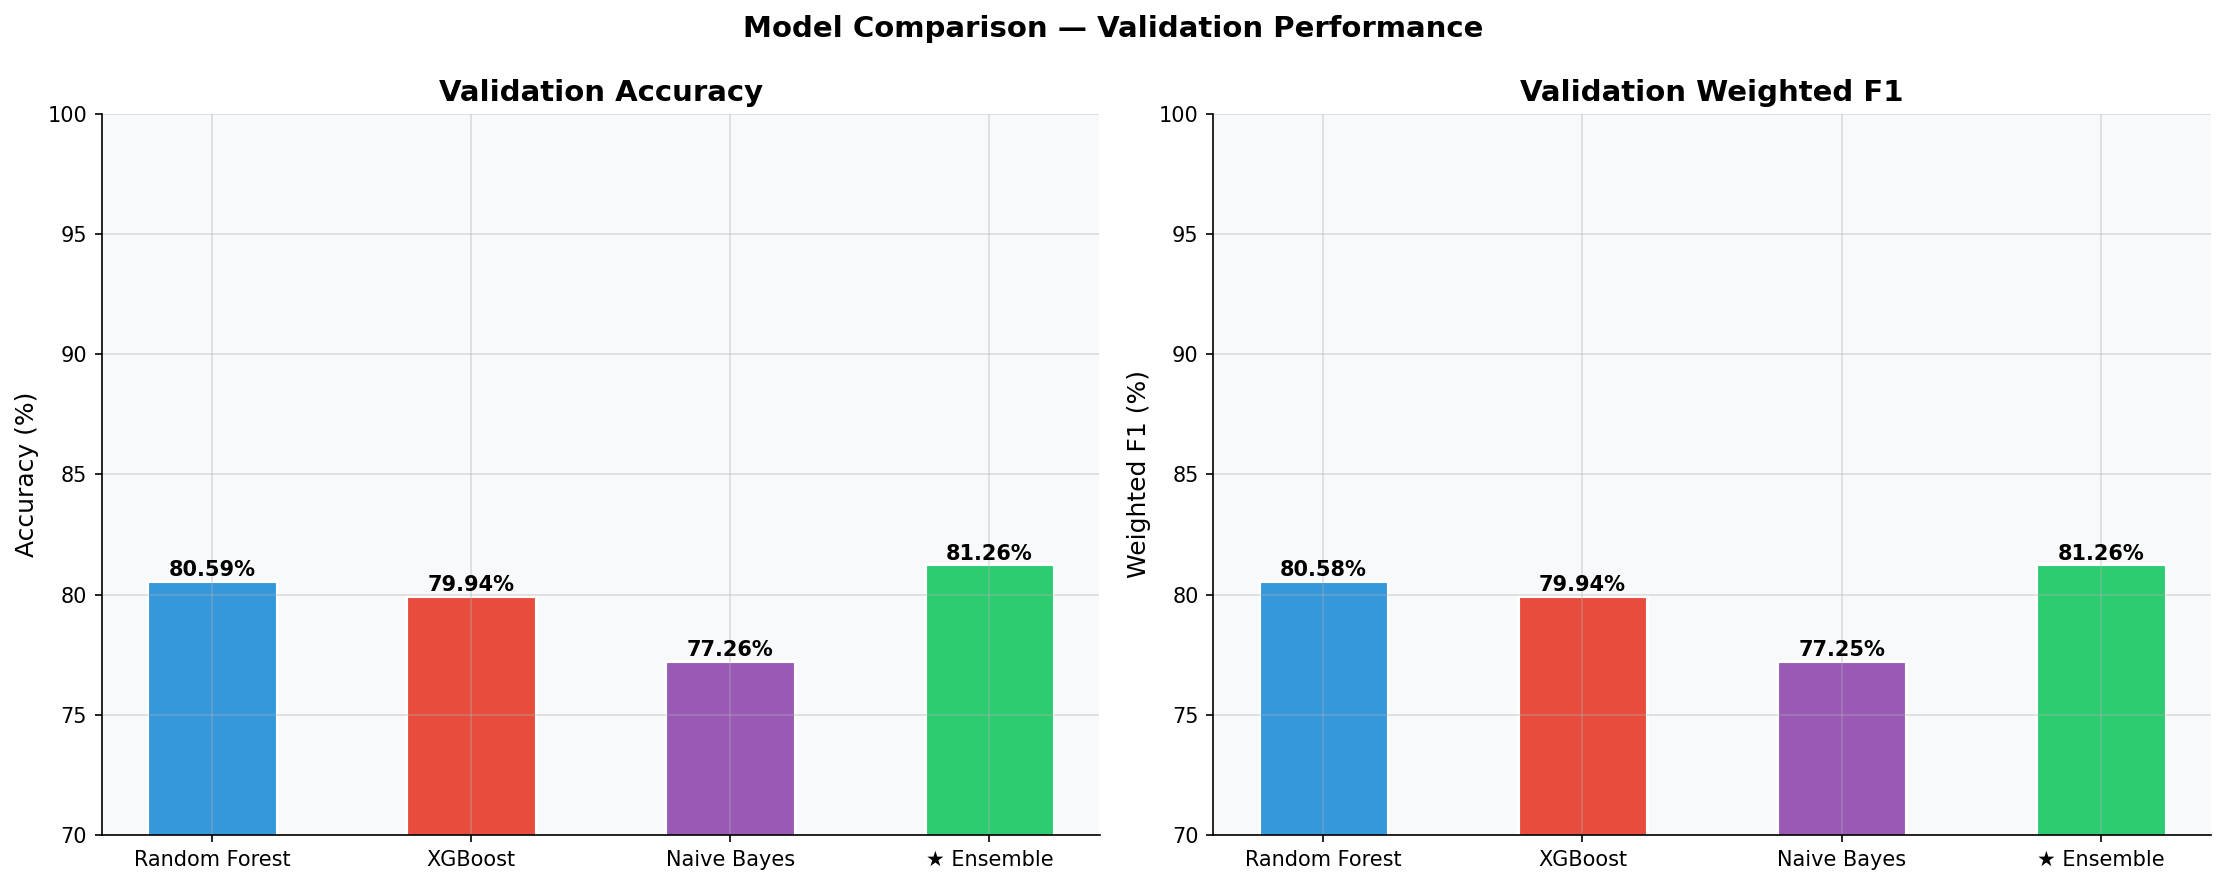

✅ Model comparison chart saved as 04_model_comparison.png


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# SOFT VOTING: combine probability outputs from RF + XGB + NB
# Each model gets a weight proportional to its validation accuracy
# ─────────────────────────────────────────────────────────────────────────────

# Collect validation probabilities
rf_val_prob  = rf_model.predict_proba(X_val_dense)
xgb_val_prob = xgb_model.predict_proba(X_val_dense)
nb_val_prob  = nb_model.predict_proba(X_val_v1)

# Accuracy-weighted soft voting
w_rf  = rf_val_acc
w_xgb = xgb_val_acc
w_nb  = nb_val_acc
w_sum = w_rf + w_xgb + w_nb

avg_val_prob = (w_rf * rf_val_prob + w_xgb * xgb_val_prob + w_nb * nb_val_prob) / w_sum
y_val_pred   = avg_val_prob.argmax(axis=1)

ens_val_acc = accuracy_score(y_val, y_val_pred)
ens_val_f1  = f1_score(y_val, y_val_pred, average='weighted')
print(f'Ensemble Weights  →  RF: {w_rf/w_sum:.3f}  XGB: {w_xgb/w_sum:.3f}  NB: {w_nb/w_sum:.3f}')
print(f'Ensemble Val Accuracy : {ens_val_acc:.4f}  |  F1: {ens_val_f1:.4f}')

# ── Model comparison bar chart ────────────────────────────────────────────────
model_names = ['Random Forest', 'XGBoost', 'Naive Bayes', '★ Ensemble']
val_accs    = [rf_val_acc, xgb_val_acc, nb_val_acc, ens_val_acc]
val_f1s     = [rf_val_f1,  xgb_val_f1,  nb_val_f1,  ens_val_f1]
bar_colors  = ['#3498DB', '#E74C3C', '#9B59B6', '#2ECC71']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Model Comparison — Validation Performance', fontweight='bold', fontsize=14)

for ax, scores, title in zip(axes, [val_accs, val_f1s], ['Accuracy', 'Weighted F1']):
    bars = ax.bar(model_names, [s*100 for s in scores],
                  color=bar_colors, width=0.5, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val*100:.2f}%', ha='center', fontweight='bold', fontsize=10)
    ax.set_ylim(70, 100)
    ax.set_title(f'Validation {title}', fontweight='bold')
    ax.set_ylabel(f'{title} (%)')

plt.tight_layout()
plt.savefig('04_model_comparison.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Model comparison chart saved as 04_model_comparison.png')

## 🧪 Cell 9 — Test Set Evaluation

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# FINAL EVALUATION ON HELD-OUT TEST SET
# ─────────────────────────────────────────────────────────────────────────────
rf_test_prob  = rf_model.predict_proba(X_test_dense)
xgb_test_prob = xgb_model.predict_proba(X_test_dense)
nb_test_prob  = nb_model.predict_proba(X_test_v1)

avg_test_prob = (w_rf * rf_test_prob + w_xgb * xgb_test_prob + w_nb * nb_test_prob) / w_sum
y_pred        = avg_test_prob.argmax(axis=1)
y_prob_pos    = avg_test_prob[:, 1]

test_acc  = accuracy_score(y_test, y_pred)
test_f1   = f1_score(y_test, y_pred, average='weighted')
test_prec = precision_score(y_test, y_pred, average='weighted')
test_rec  = recall_score(y_test, y_pred, average='weighted')
test_auc  = roc_auc_score(y_test, y_prob_pos)

print('='*55)
print('  TEST SET RESULTS — RF + XGB + NB Voting Ensemble')
print('='*55)
print(f'  Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'  F1 Score  : {test_f1:.4f}')
print(f'  Precision : {test_prec:.4f}')
print(f'  Recall    : {test_rec:.4f}')
print(f'  ROC-AUC   : {test_auc:.4f}')
print('='*55)
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

  TEST SET RESULTS — RF + XGB + NB Voting Ensemble
  Accuracy  : 0.8092  (80.92%)
  F1 Score  : 0.8092
  Precision : 0.8092
  Recall    : 0.8092
  ROC-AUC   : 0.8950

Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.80      0.81      6158
    Positive       0.81      0.81      0.81      6154

    accuracy                           0.81     12312
   macro avg       0.81      0.81      0.81     12312
weighted avg       0.81      0.81      0.81     12312



## 📊 Cell 10 — Confusion Matrix

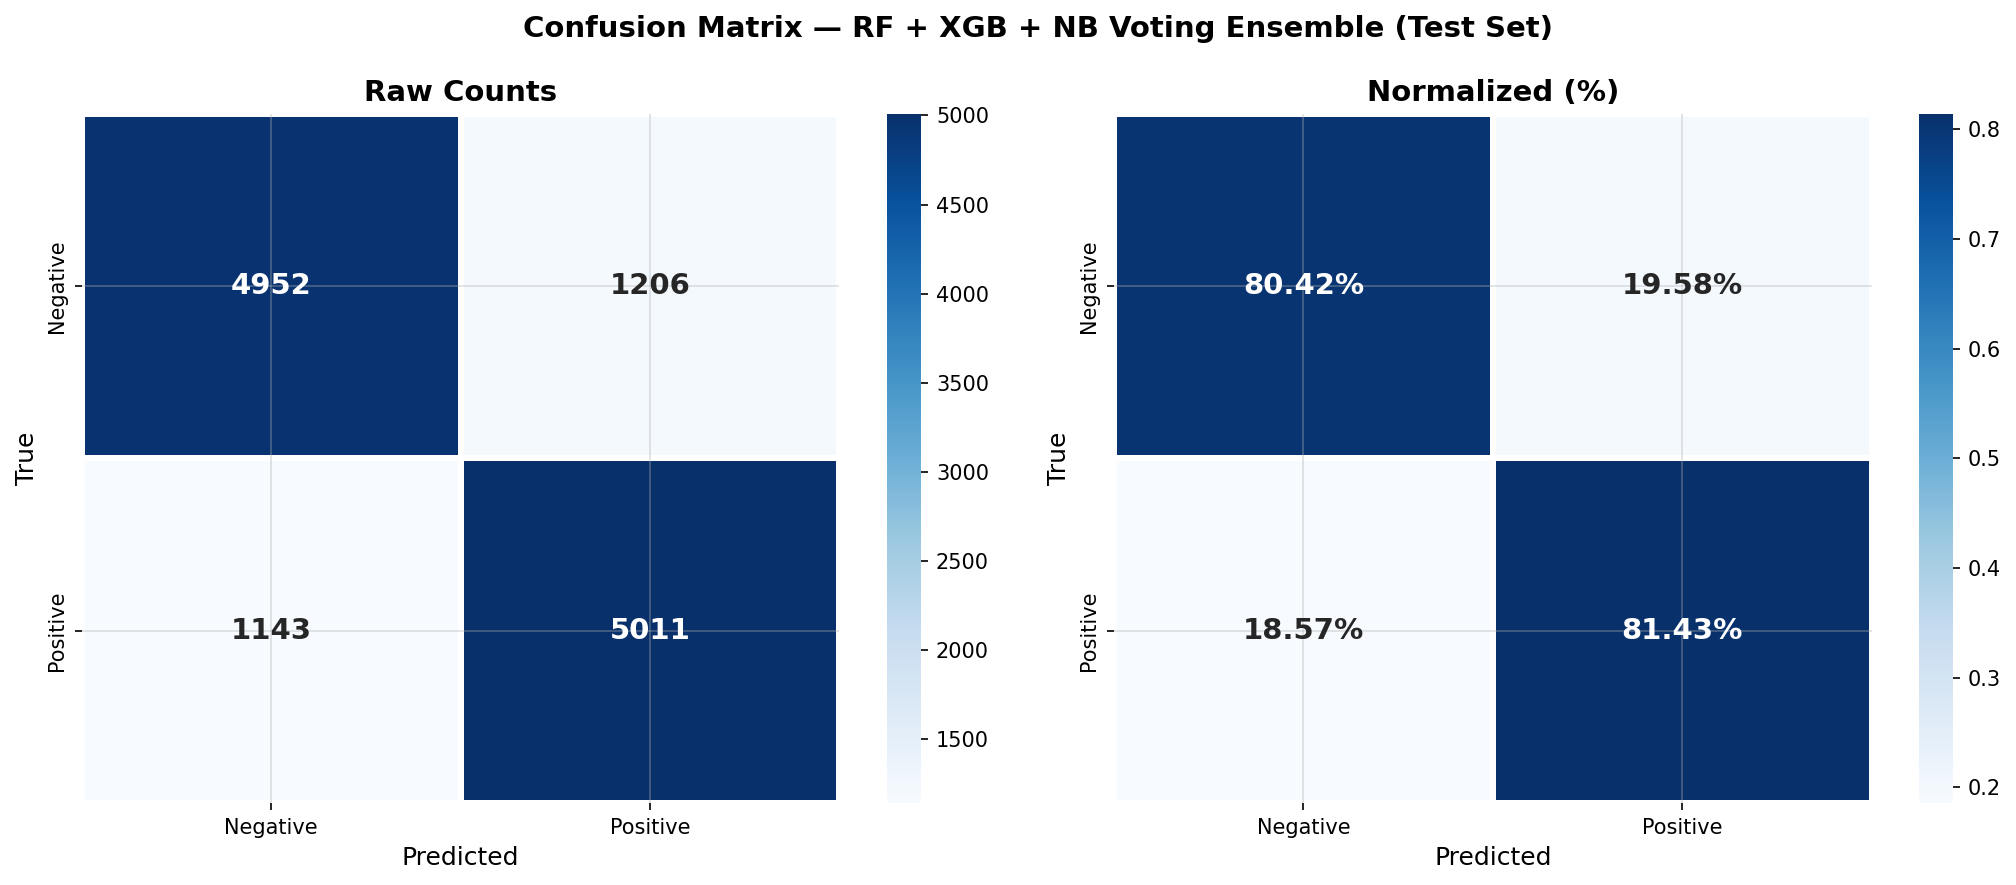

✅ Confusion matrix saved as 05_confusion_matrix.png


In [14]:
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confusion Matrix — RF + XGB + NB Voting Ensemble (Test Set)',
             fontweight='bold', fontsize=14)

for ax, data, fmt, title in zip(
    axes, [cm, cm_norm], ['d', '.2%'],
    ['Raw Counts', 'Normalized (%)']):
    sns.heatmap(data, annot=True, fmt=fmt,
                xticklabels=le.classes_, yticklabels=le.classes_,
                cmap='Blues', ax=ax, linewidths=2, linecolor='white',
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('05_confusion_matrix.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Confusion matrix saved as 05_confusion_matrix.png')

## 📈 Cell 11 — ROC & Precision-Recall Curves

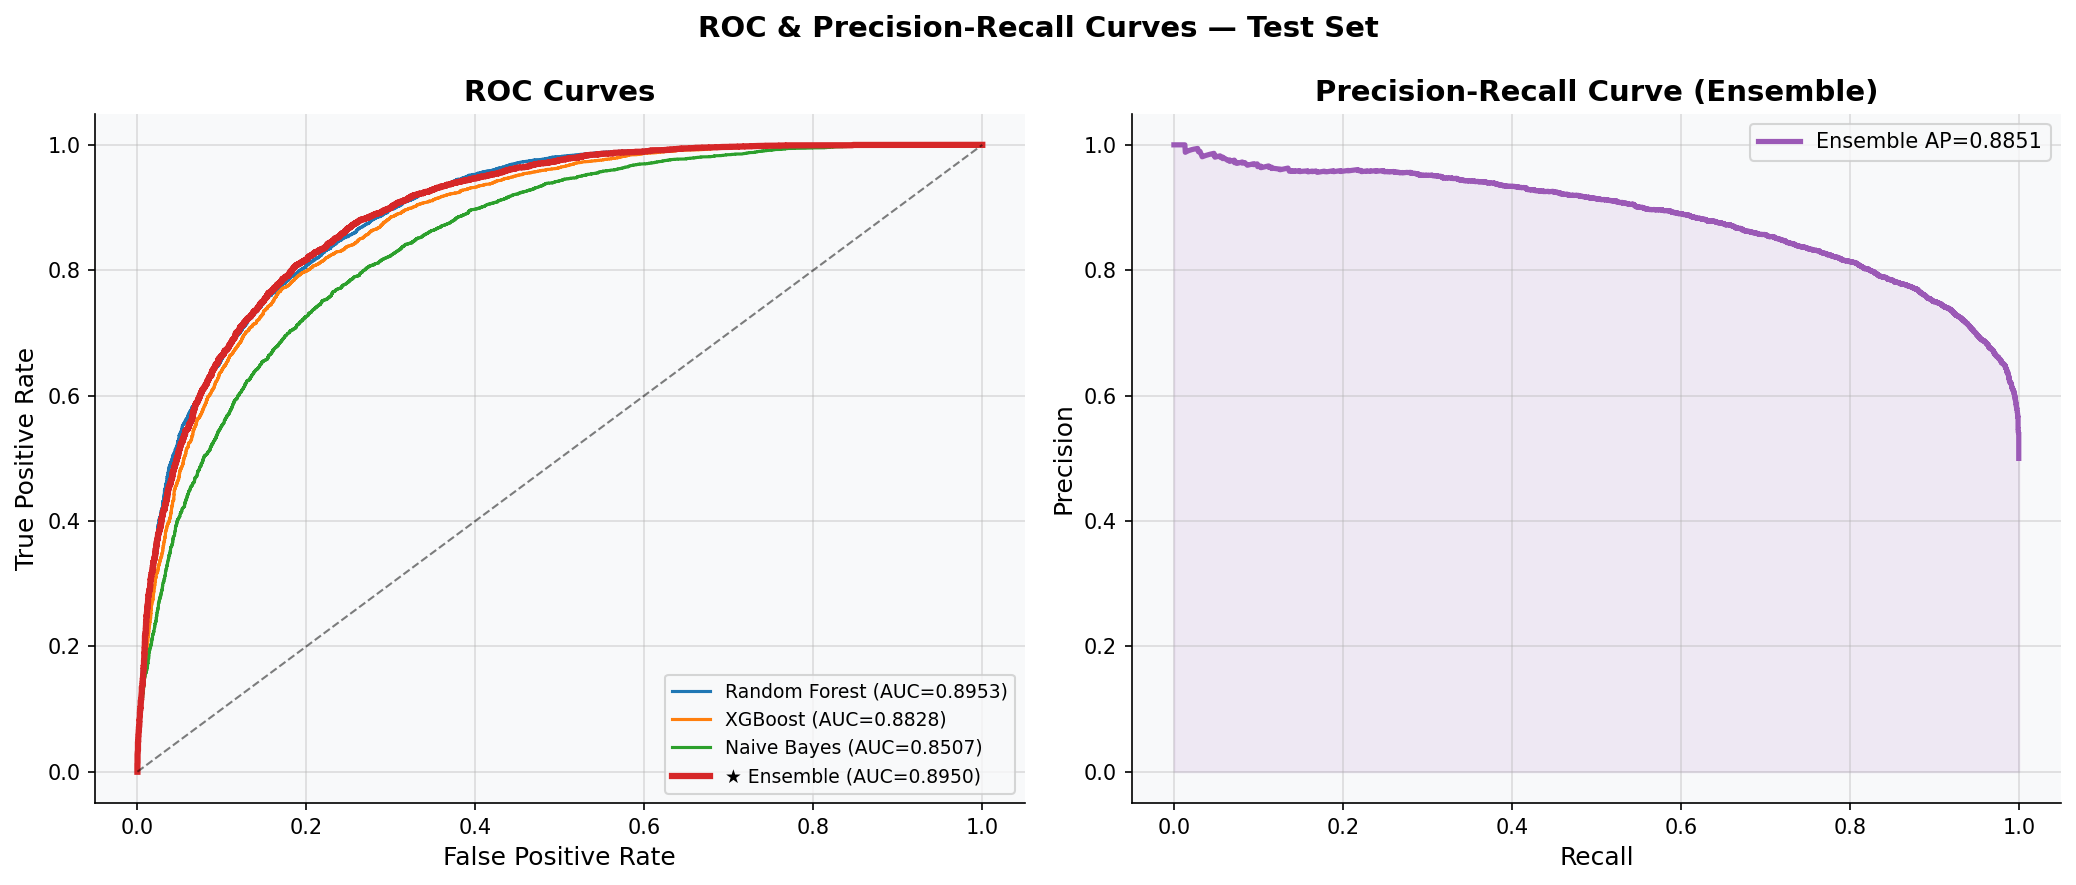

✅ ROC & PR curves saved as 06_roc_pr_curves.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('ROC & Precision-Recall Curves — Test Set', fontweight='bold', fontsize=14)

# ROC curves per model + ensemble
ax = axes[0]
for name, probs in [
    ('Random Forest', rf_test_prob[:, 1]),
    ('XGBoost',       xgb_test_prob[:, 1]),
    ('Naive Bayes',   nb_test_prob[:, 1]),
    ('★ Ensemble',   y_prob_pos),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    lw = 3 if '★' in name else 1.5
    ax.plot(fpr, tpr, lw=lw, label=f'{name} (AUC={auc_val:.4f})')
ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves', fontweight='bold'); ax.legend(fontsize=9)

# PR curve — ensemble only
ax = axes[1]
prec_c, rec_c, _ = precision_recall_curve(y_test, y_prob_pos)
ap = average_precision_score(y_test, y_prob_pos)
ax.plot(rec_c, prec_c, color='#9B59B6', lw=2.5, label=f'Ensemble AP={ap:.4f}')
ax.fill_between(rec_c, prec_c, alpha=0.1, color='#9B59B6')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve (Ensemble)', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('06_roc_pr_curves.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ ROC & PR curves saved as 06_roc_pr_curves.png')

## 🔁 Cell 12 — 5-Fold Stratified Cross-Validation

## 📈 Cell 13 — Learning Curve Analysis

Generating Learning Curve for XGBoost...
Generating learning curve...
  Trained on  5,745 samples: Train Accuracy: 0.9904, Val Accuracy: 0.7130
  Trained on 11,490 samples: Train Accuracy: 0.9849, Val Accuracy: 0.7436
  Trained on 17,235 samples: Train Accuracy: 0.9810, Val Accuracy: 0.7541
  Trained on 22,981 samples: Train Accuracy: 0.9747, Val Accuracy: 0.7694
  Trained on 28,726 samples: Train Accuracy: 0.9665, Val Accuracy: 0.7803
  Trained on 34,471 samples: Train Accuracy: 0.9563, Val Accuracy: 0.7852
  Trained on 40,217 samples: Train Accuracy: 0.9482, Val Accuracy: 0.7918
  Trained on 45,962 samples: Train Accuracy: 0.9395, Val Accuracy: 0.7961
  Trained on 51,707 samples: Train Accuracy: 0.9331, Val Accuracy: 0.7978
  Trained on 57,453 samples: Train Accuracy: 0.9265, Val Accuracy: 0.7994


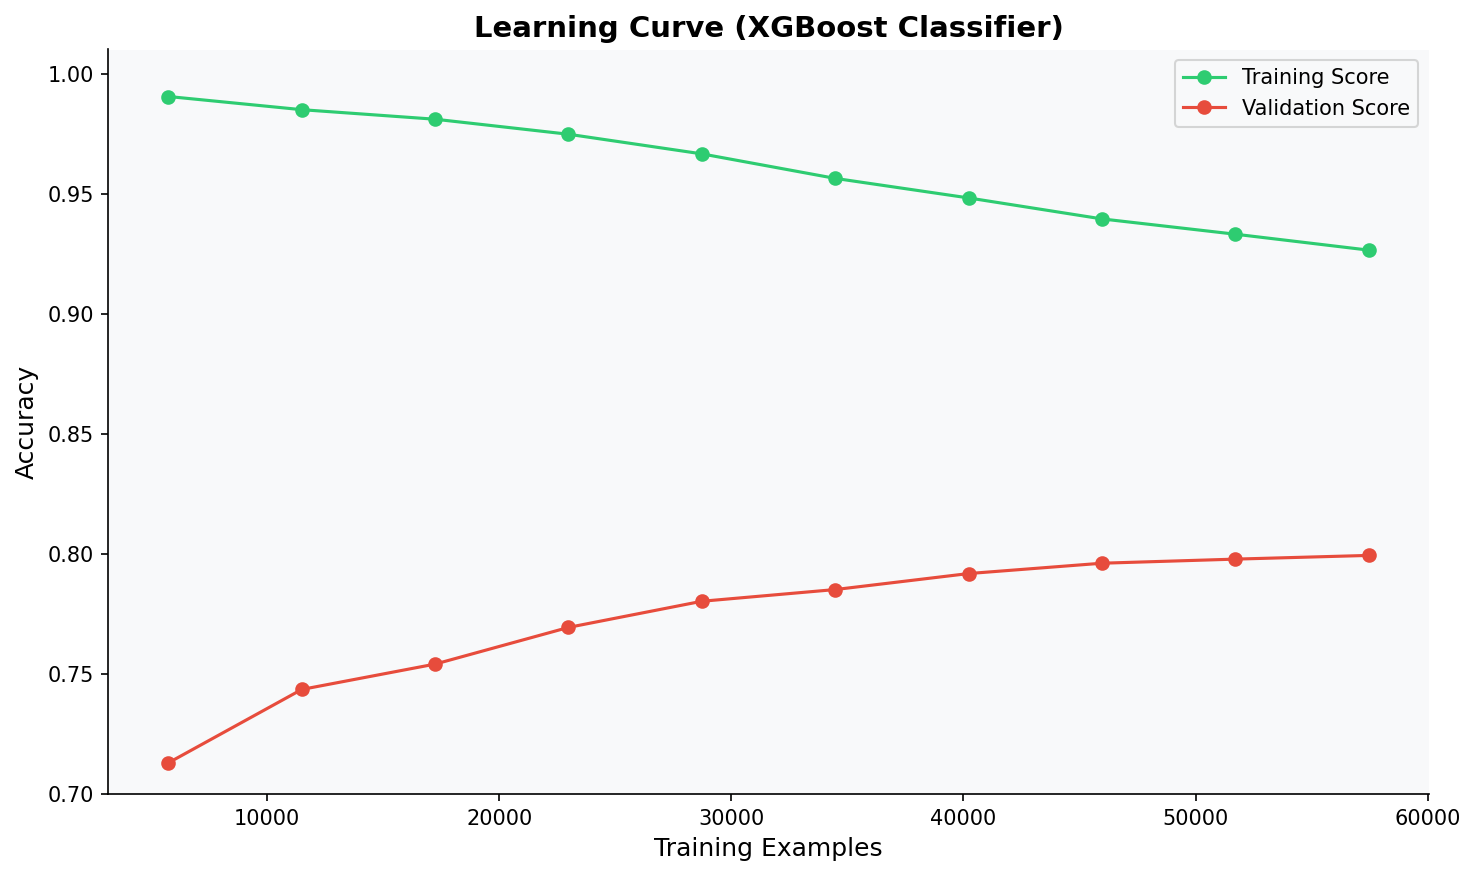

✅ Learning curve chart saved as 10_learning_curve.png


In [16]:
from sklearn.model_selection import learning_curve
import numpy as np # Import numpy

def plot_learning_curve(estimator, X, y, X_val, y_val,
                        title="", axes=None, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5),
                        scoring='accuracy'):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the plot.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features),
        Target vector relative to X.

    X_val : array-like, shape (n_samples, n_features)
        Validation vector.

    y_val : array-like, shape (n_samples)
        Target vector relative to X_val.

    axes : array-like, shape (n_plots, ), optional
        Array of axes to plot the learning curve.

    ylim : tuple, shape (ymin, ymax), optional
        Defines the y-axis limits of the plot.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy. If None,
        to use the default 5-fold cross-validation.

    n_jobs : int or None, optional
        Number of jobs to run in parallel. None means 1 unless
        in a joblib.parallel_backend context. -1 means using all
        processors.

    train_sizes : array-like, shape (n_ticks, ), optional
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve.

    scoring : string, callable or None, optional, default: 'accuracy'
        A string (see model evaluation documentation) or a scorer callable
        object / function with signature `scorer(estimator, X, y)`.
    """
    if axes is None:
        _, axes = plt.subplots(1, 1, figsize=(10, 6))

    axes.set_title(title, fontweight='bold')
    if ylim is not None:
        axes.set_ylim(*ylim)
    axes.set_xlabel('Training Examples')
    axes.set_ylabel(scoring.replace('_', ' ').title())

    # Initialize lists to store scores
    train_scores_mean = []
    val_scores_mean = []

    print('Generating learning curve...')
    for train_size in train_sizes:
        # Calculate absolute number of samples for current train_size ratio
        current_train_samples = int(X.shape[0] * train_size)

        # Take a subset of the training data
        X_subset = X[:current_train_samples]
        y_subset = y[:current_train_samples]

        # Clone the estimator and train it on the subset
        # Note: For learning curve, we often retrain from scratch
        current_estimator = estimator.__class__(**estimator.get_params())
        current_estimator.fit(X_subset, y_subset)

        # Evaluate on training subset and full validation set
        train_score = current_estimator.score(X_subset, y_subset)
        val_score = current_estimator.score(X_val, y_val)

        train_scores_mean.append(train_score)
        val_scores_mean.append(val_score)
        print(f'  Trained on {current_train_samples:>6,} samples: Train {scoring.capitalize()}: {train_score:.4f}, Val {scoring.capitalize()}: {val_score:.4f}')

    train_scores_mean = np.array(train_scores_mean)
    val_scores_mean = np.array(val_scores_mean)

    # Plot training and validation curves
    axes.grid()
    axes.plot(X.shape[0] * train_sizes, train_scores_mean, 'o-', color=COLORS['Positive'],
             label='Training Score')
    axes.plot(X.shape[0] * train_sizes, val_scores_mean, 'o-', color=COLORS['Negative'],
             label='Validation Score')

    axes.legend(loc='best')
    return plt

print('Generating Learning Curve for XGBoost...')
xgb_lc_model = XGBClassifier(
    n_estimators=400, # Use same as before, but without eval_set for learning_curve
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    use_label_encoder=False,
    eval_metric='logloss',
    tree_method='hist',
    random_state=SEED,
    n_jobs=-1
)

fig, ax = plt.subplots(figsize=(10, 6))
plot_learning_curve(
    estimator=xgb_lc_model,
    X=X_train_dense, y=y_train,
    X_val=X_val_dense, y_val=y_val,
    title="Learning Curve (XGBoost Classifier)",
    axes=ax, ylim=(0.7, 1.01),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

plt.tight_layout()
plt.savefig('10_learning_curve.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Learning curve chart saved as 10_learning_curve.png')

🔁 Running 5-Fold Cross-Validation on XGBoost pipeline (fastest CV-friendly model)...

Cross-Validation Results (5-Fold):
  Accuracy : 0.7775 ± 0.0037
  F1 Score : 0.7775 ± 0.0037
  Per-fold : ['0.7785', '0.7796', '0.7807', '0.7787', '0.7703']


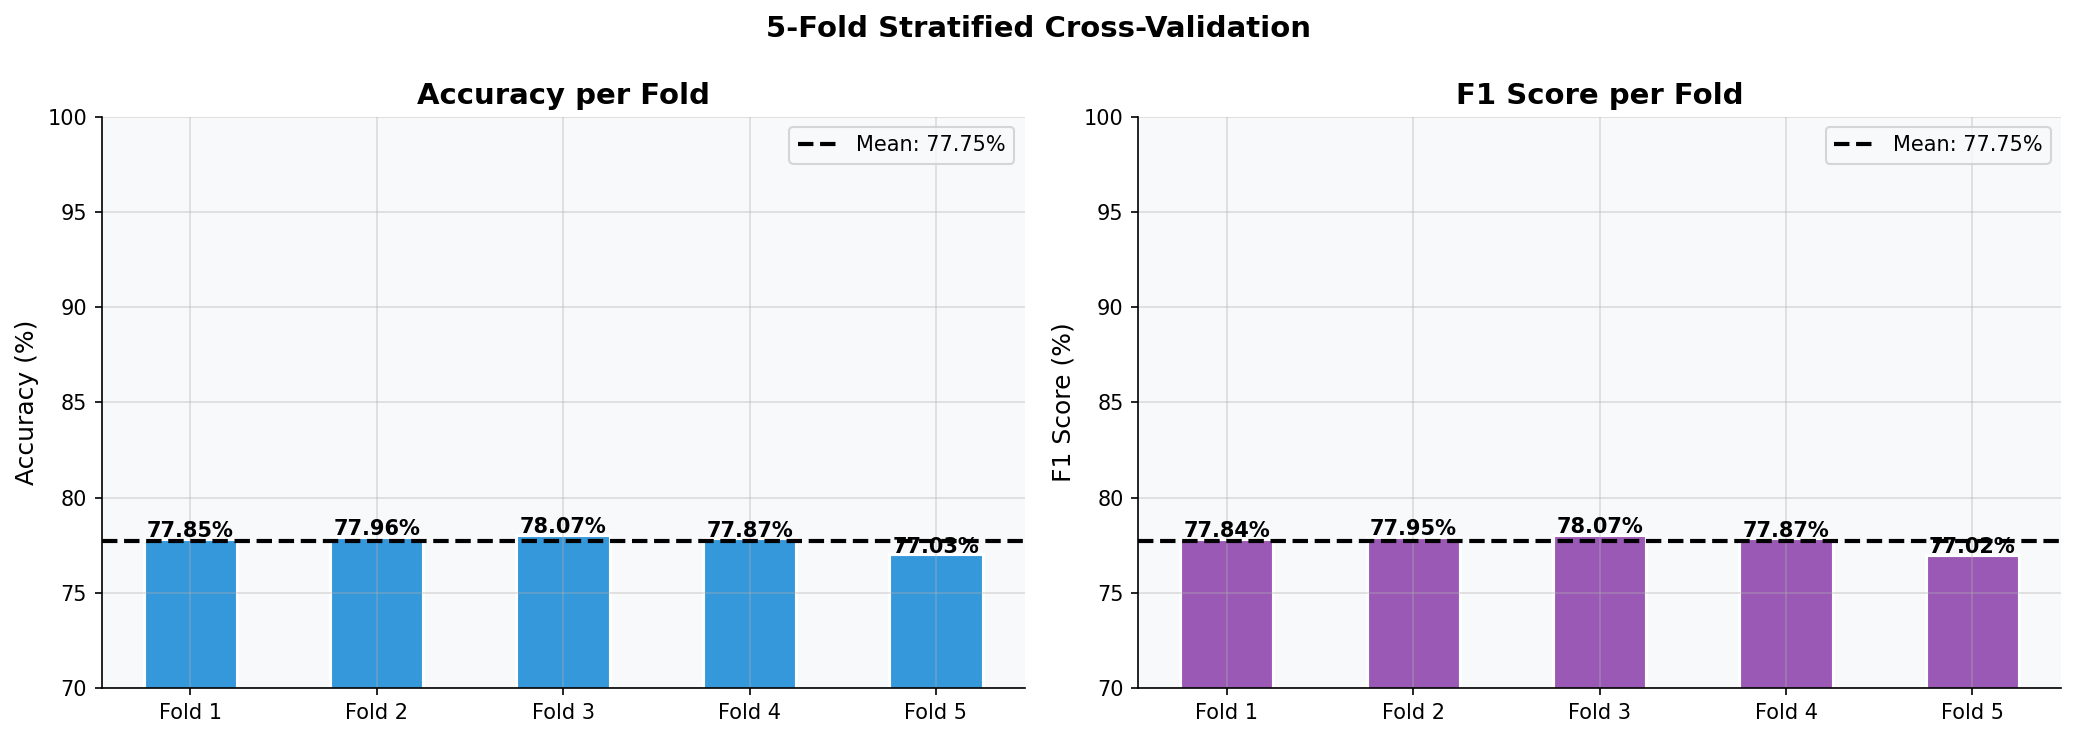

✅ Cross-validation chart saved as 07_cross_validation.png


In [17]:
print('🔁 Running 5-Fold Cross-Validation on XGBoost pipeline (fastest CV-friendly model)...')

from sklearn.pipeline import Pipeline as SKPipeline

cv_pipe = SKPipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5),
                              max_features=100_000, sublinear_tf=True, min_df=2)),
    ('svd',   TruncatedSVD(n_components=500, random_state=SEED)),
    ('clf',   XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                             scale_pos_weight=scale_pos, eval_metric='logloss',
                             tree_method='hist', random_state=SEED, n_jobs=-1))
])

X_cv = pd.concat([X_train, X_val]).reset_index(drop=True)
y_cv = np.concatenate([y_train, y_val])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_acc = cross_val_score(cv_pipe, X_cv, y_cv, cv=skf, scoring='accuracy', n_jobs=-1)
cv_f1  = cross_val_score(cv_pipe, X_cv, y_cv, cv=skf, scoring='f1_weighted', n_jobs=-1)

print(f'\nCross-Validation Results (5-Fold):')
print(f'  Accuracy : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print(f'  F1 Score : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
print(f'  Per-fold : {[f"{v:.4f}" for v in cv_acc]}')

fold_labels = [f'Fold {i+1}' for i in range(5)]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('5-Fold Stratified Cross-Validation', fontweight='bold', fontsize=14)

for ax, scores, title, color in zip(
    axes, [cv_acc, cv_f1], ['Accuracy', 'F1 Score'], ['#3498DB', '#9B59B6']):
    bars = ax.bar(fold_labels, scores * 100, color=color,
                  width=0.5, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val*100:.2f}%', ha='center', fontweight='bold', fontsize=10)
    ax.axhline(y=scores.mean()*100, color='black', linestyle='--', lw=2,
               label=f'Mean: {scores.mean()*100:.2f}%')
    ax.set_ylim(70, 100); ax.set_title(f'{title} per Fold', fontweight='bold')
    ax.set_ylabel(f'{title} (%)'); ax.legend()

plt.tight_layout()
plt.savefig('07_cross_validation.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Cross-validation chart saved as 07_cross_validation.png')

## 🏆 Cell 13 — Final Metrics Dashboard

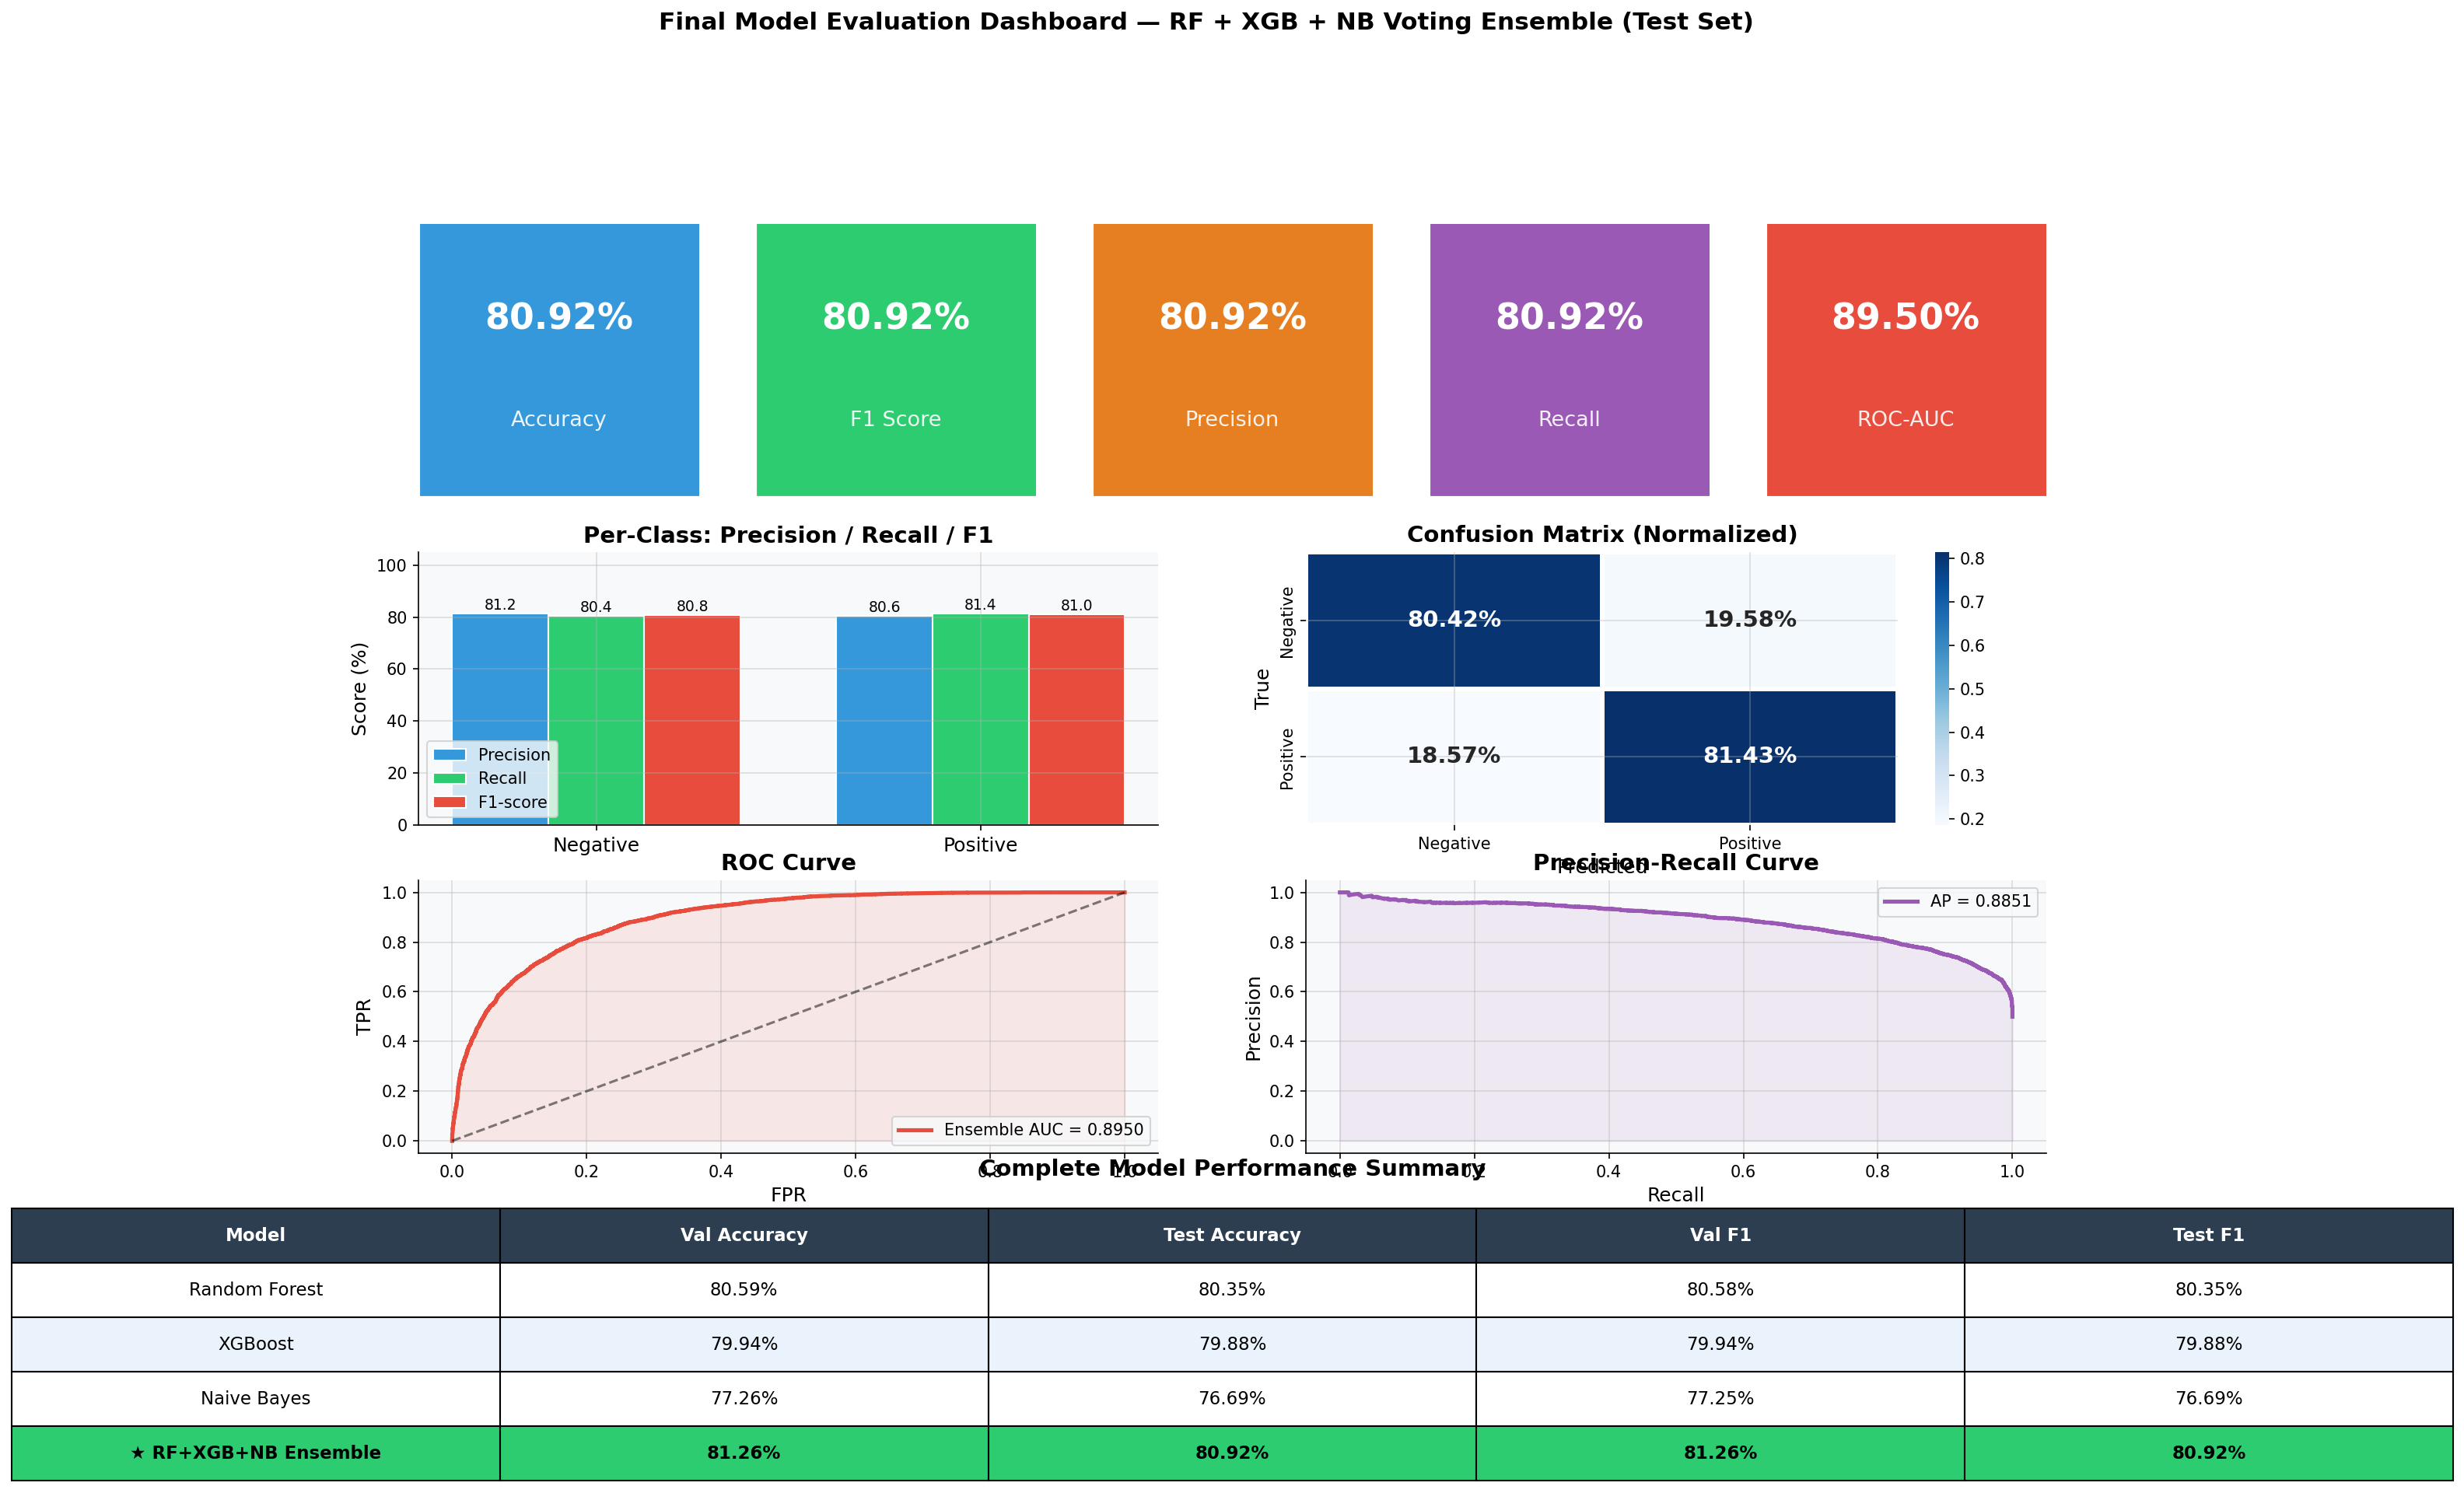

✅ Final dashboard saved as 08_final_dashboard.png


In [18]:
report_dict = classification_report(y_test, y_pred,
                                     target_names=le.classes_, output_dict=True)

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Final Model Evaluation Dashboard — RF + XGB + NB Voting Ensemble (Test Set)',
             fontsize=15, fontweight='bold', y=1.01)

# ── Row 1: Metric cards ──
metrics = [
    ('Accuracy',  test_acc,  '#3498DB'),
    ('F1 Score',  test_f1,   '#2ECC71'),
    ('Precision', test_prec, '#E67E22'),
    ('Recall',    test_rec,  '#9B59B6'),
    ('ROC-AUC',   test_auc,  '#E74C3C'),
]
for i, (name, val, color) in enumerate(metrics):
    ax = fig.add_subplot(4, 5, i + 1)
    ax.set_facecolor(color)
    ax.text(0.5, 0.65, f'{val*100:.2f}%', ha='center', va='center',
            fontsize=22, fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(0.5, 0.28, name, ha='center', va='center',
            fontsize=13, color='white', alpha=0.9, transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('white'); spine.set_linewidth(2)

# ── Row 2 Left: Per-class metrics ──
ax2 = fig.add_subplot(4, 2, 3)
x_pos = np.arange(len(le.classes_))
width = 0.25
for i, (metric, color) in enumerate(zip(
    ['precision','recall','f1-score'], ['#3498DB','#2ECC71','#E74C3C'])):
    vals = [report_dict[cls][metric] for cls in le.classes_]
    bars = ax2.bar(x_pos + i*width, [v*100 for v in vals],
                   width, label=metric.capitalize(), color=color, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val*100:.1f}', ha='center', va='bottom', fontsize=9)
ax2.set_xticks(x_pos + width); ax2.set_xticklabels(le.classes_, fontsize=12)
ax2.set_ylim(0, 105); ax2.set_title('Per-Class: Precision / Recall / F1', fontweight='bold')
ax2.set_ylabel('Score (%)'); ax2.legend()

# ── Row 2 Right: Confusion Matrix ──
ax3 = fig.add_subplot(4, 2, 4)
sns.heatmap(cm_norm, annot=True, fmt='.2%',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cmap='Blues', ax=ax3, linewidths=2, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
ax3.set_title('Confusion Matrix (Normalized)', fontweight='bold')
ax3.set_xlabel('Predicted'); ax3.set_ylabel('True')

# ── Row 3 Left: ROC ──
ax4 = fig.add_subplot(4, 2, 5)
fpr, tpr, _ = roc_curve(y_test, y_prob_pos)
ax4.plot(fpr, tpr, color='#E74C3C', lw=2.5, label=f'Ensemble AUC = {test_auc:.4f}')
ax4.plot([0,1],[0,1],'k--', lw=1.5, alpha=0.5)
ax4.fill_between(fpr, tpr, alpha=0.1, color='#E74C3C')
ax4.set_xlabel('FPR'); ax4.set_ylabel('TPR')
ax4.set_title('ROC Curve', fontweight='bold'); ax4.legend(loc='lower right')

# ── Row 3 Right: PR Curve ──
ax5 = fig.add_subplot(4, 2, 6)
ax5.plot(rec_c, prec_c, color='#9B59B6', lw=2.5, label=f'AP = {ap:.4f}')
ax5.fill_between(rec_c, prec_c, alpha=0.1, color='#9B59B6')
ax5.set_xlabel('Recall'); ax5.set_ylabel('Precision')
ax5.set_title('Precision-Recall Curve', fontweight='bold'); ax5.legend()

# ── Row 4: Summary table ──
ax6 = fig.add_subplot(4, 1, 4); ax6.axis('off')
summary_data = [
    ['Random Forest',  f'{rf_val_acc*100:.2f}%',
     f'{accuracy_score(y_test, rf_model.predict(X_test_dense))*100:.2f}%',
     f'{rf_val_f1*100:.2f}%',
     f'{f1_score(y_test, rf_model.predict(X_test_dense), average="weighted")*100:.2f}%'],
    ['XGBoost',        f'{xgb_val_acc*100:.2f}%',
     f'{accuracy_score(y_test, xgb_model.predict(X_test_dense))*100:.2f}%',
     f'{xgb_val_f1*100:.2f}%',
     f'{f1_score(y_test, xgb_model.predict(X_test_dense), average="weighted")*100:.2f}%'],
    ['Naive Bayes',    f'{nb_val_acc*100:.2f}%',
     f'{accuracy_score(y_test, nb_model.predict(X_test_v1))*100:.2f}%',
     f'{nb_val_f1*100:.2f}%',
     f'{f1_score(y_test, nb_model.predict(X_test_v1), average="weighted")*100:.2f}%'],
    ['★ RF+XGB+NB Ensemble', f'{ens_val_acc*100:.2f}%', f'{test_acc*100:.2f}%',
     f'{ens_val_f1*100:.2f}%', f'{test_f1*100:.2f}%'],
]
tbl = ax6.table(
    cellText=summary_data,
    colLabels=['Model', 'Val Accuracy', 'Test Accuracy', 'Val F1', 'Test F1'],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.5, 2.8)
for (r, c), cell in tbl.get_celld().items():
    if r == 0: cell.set_facecolor(COLORS['primary']); cell.set_text_props(color='white', fontweight='bold')
    elif r == len(summary_data): cell.set_facecolor('#2ECC71'); cell.set_text_props(fontweight='bold')
    else: cell.set_facecolor('#EAF2FB' if r % 2 == 0 else 'white')
ax6.set_title('Complete Model Performance Summary', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('08_final_dashboard.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Final dashboard saved as 08_final_dashboard.png')

## 💡 Cell 14 — Error Analysis

Total test samples   : 12,312
Correctly classified : 9,963 (80.92%)
Misclassified        : 2,349 (19.08%)

Error breakdown:
true_label  pred_label
Negative    Positive      1206
Positive    Negative      1143
dtype: int64


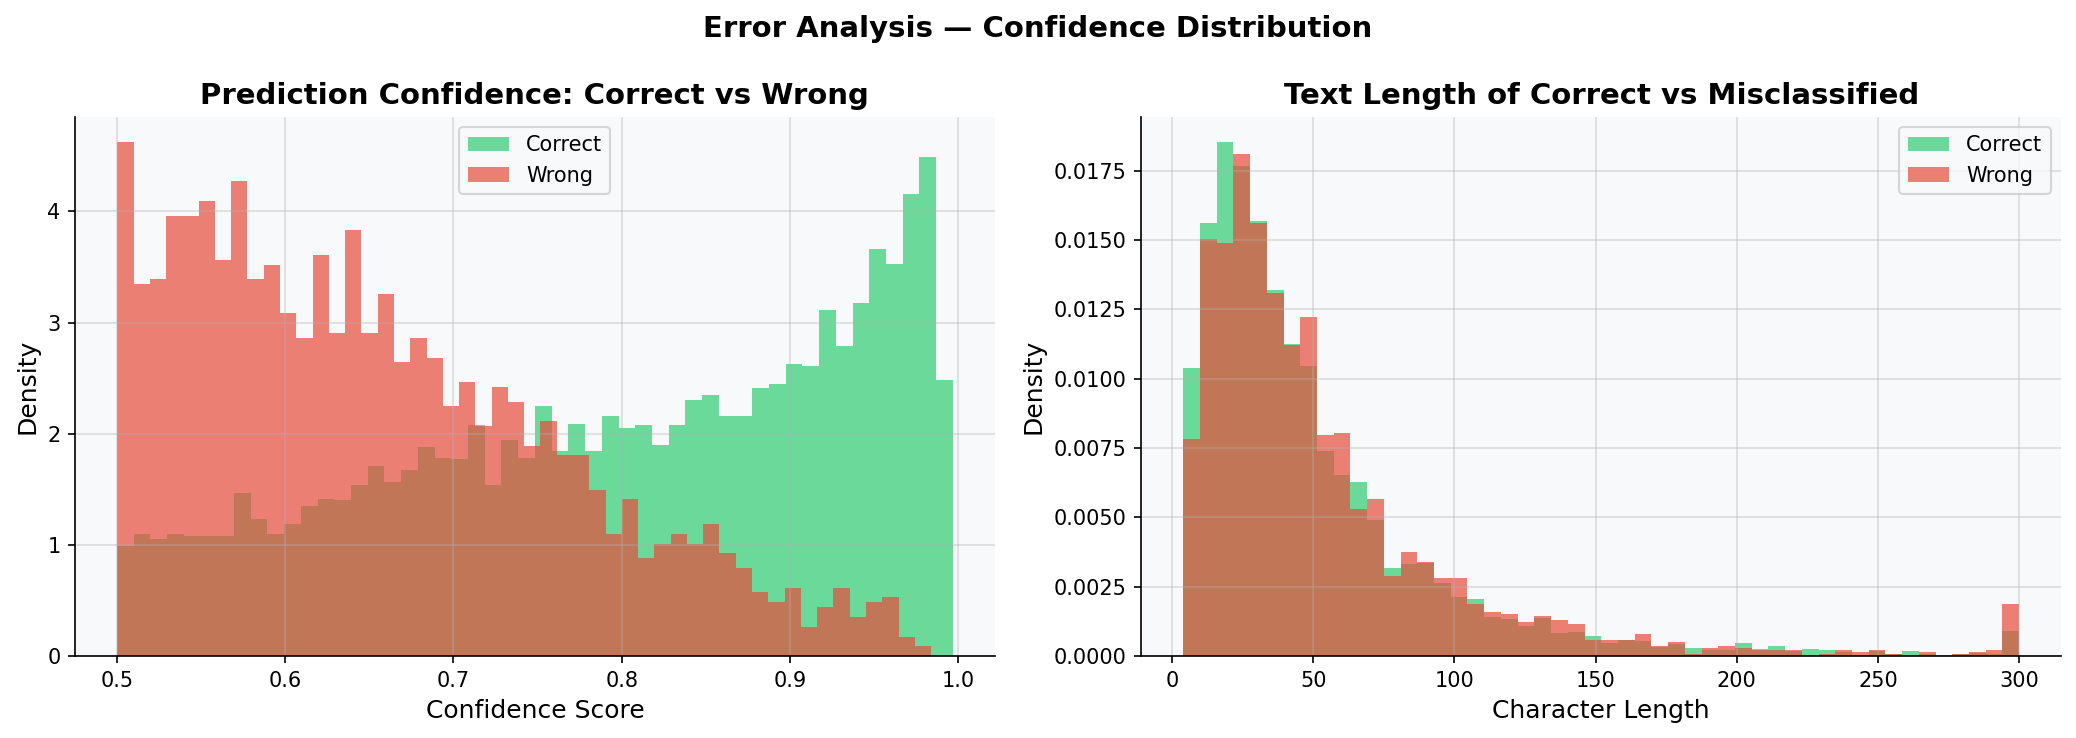


📋 Sample Misclassified Examples:
──────────────────────────────────────────────────────────────────────
Text      : একটু থামুন!  , ,  ও   বৃদ্ধি ও পরিপূর্ণ করার জন্য শ্রেষ্ঠ দুটি বই। শুধু একবার দে
True: Positive  |  Predicted: Negative  |  Confidence: 0.513
──────────────────────────────────────────────────────────────────────
Text      : আমরা গণতন্ত্র ও ভোটাধিকার চাই।
True: Positive  |  Predicted: Negative  |  Confidence: 0.680
──────────────────────────────────────────────────────────────────────
Text      : শেষ লাইনে এটা কি কইলেন দাদা  “ নায়িকার বাবা হইয়া জড়ায়ে ধরতে পারবেন দুলাভাই”
True: Negative  |  Predicted: Positive  |  Confidence: 0.594
──────────────────────────────────────────────────────────────────────
Text      : আল্লাহ আপনাকে দীর্ঘজীবি করুন। আমিন।
True: Negative  |  Predicted: Positive  |  Confidence: 0.674
──────────────────────────────────────────────────────────────────────
Text      : এত মজা কে
True: Positive  |  Predicted: Negative  |  Confidence: 0.712
────────

In [19]:
test_idx = X_test.index
test_results_df = df.loc[test_idx].copy().reset_index(drop=True)
test_results_df['y_true']     = y_test
test_results_df['y_pred']     = y_pred
test_results_df['confidence'] = avg_test_prob.max(axis=1)
test_results_df['correct']    = (test_results_df['y_true'] == test_results_df['y_pred'])
test_results_df['true_label'] = le.inverse_transform(y_test)
test_results_df['pred_label'] = le.inverse_transform(y_pred)

errors = test_results_df[~test_results_df['correct']]
print(f'Total test samples   : {len(test_results_df):,}')
print(f'Correctly classified : {test_results_df["correct"].sum():,} ({test_results_df["correct"].mean()*100:.2f}%)')
print(f'Misclassified        : {len(errors):,} ({len(errors)/len(test_results_df)*100:.2f}%)')
print('\nError breakdown:')
print(errors.groupby(['true_label', 'pred_label']).size())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Error Analysis — Confidence Distribution', fontweight='bold', fontsize=14)

ax = axes[0]
ax.hist(test_results_df[test_results_df['correct']]['confidence'],
        bins=50, color='#2ECC71', alpha=0.7, density=True, label='Correct')
ax.hist(test_results_df[~test_results_df['correct']]['confidence'],
        bins=50, color='#E74C3C', alpha=0.7, density=True, label='Wrong')
ax.set_title('Prediction Confidence: Correct vs Wrong', fontweight='bold')
ax.set_xlabel('Confidence Score'); ax.set_ylabel('Density'); ax.legend()

ax = axes[1]
ax.hist(test_results_df[test_results_df['correct']]['text_length'].clip(upper=300),
        bins=50, color='#2ECC71', alpha=0.7, density=True, label='Correct')
ax.hist(errors['text_length'].clip(upper=300),
        bins=50, color='#E74C3C', alpha=0.7, density=True, label='Wrong')
ax.set_title('Text Length of Correct vs Misclassified', fontweight='bold')
ax.set_xlabel('Character Length'); ax.set_ylabel('Density'); ax.legend()

plt.tight_layout()
plt.savefig('09_error_analysis.png', bbox_inches='tight', dpi=300)
plt.show()

print('\n📋 Sample Misclassified Examples:')
print('─' * 70)
for _, row in errors.sample(min(5, len(errors)), random_state=42).iterrows():
    print(f"Text      : {row['Comment'][:80]}")
    print(f"True: {row['true_label']}  |  Predicted: {row['pred_label']}  |  Confidence: {row['confidence']:.3f}")
    print('─' * 70)

## 📝 Cell 15 — Final Summary Report

In [20]:
print('=' * 65)
print('  THESIS FINAL RESULTS SUMMARY')
print('  Bangla Sports Sentiment Analysis')
print('  Model: RF + XGBoost + Naive Bayes Voting Ensemble')
print('=' * 65)
print(f'\n  Dataset         : Bangla Sports Sentiment Dataset')
print(f'  Total Samples   : {len(df):,}')
print(f'  Classes         : Positive / Negative (Binary)')
print(f'  Class Balance   : {df["Category"].value_counts().to_dict()}')
print(f'\n  Split           : 70% Train / 15% Val / 15% Test')
print(f'  Train Samples   : {len(X_train):,}')
print(f'  Val Samples     : {len(X_val):,}')
print(f'  Test Samples    : {len(X_test):,}')
print(f'\n  Feature Method  : TF-IDF Ensemble (char_wb + word + char n-grams)')
print(f'  Total Features  : {total_features:,}  →  SVD reduced to 2000 dims')
print(f'  Models Trained  : Random Forest, XGBoost, Multinomial Naive Bayes')
print(f'  Final Model     : Accuracy-Weighted Soft Voting Ensemble')
print()
print(f'  ┌──────────────────────────────────────────────┐')
print(f'  │  TEST SET PERFORMANCE (Final / Unseen Data)  │')
print(f'  ├──────────────────────────────────────────────┤')
print(f'  │  Accuracy          : {test_acc*100:>6.2f}%               │')
print(f'  │  Weighted F1 Score : {test_f1*100:>6.2f}%               │')
print(f'  │  Precision         : {test_prec*100:>6.2f}%               │')
print(f'  │  Recall            : {test_rec*100:>6.2f}%               │')
print(f'  │  ROC-AUC           : {test_auc*100:>6.2f}%               │')
print(f'  └──────────────────────────────────────────────┘')
print()
print(f'  CV (5-Fold) Accuracy : {cv_acc.mean()*100:.2f}% ± {cv_acc.std()*100:.2f}%')
print(f'  CV (5-Fold) F1 Score : {cv_f1.mean()*100:.2f}% ± {cv_f1.std()*100:.2f}%')
print()
print('  Generated Charts:')
for c in [
    '01_eda_analysis.png          — EDA & Data Distribution',
    '02_dataset_split.png         — Train/Val/Test Split',
    '03_feature_engineering.png   — TF-IDF Feature Analysis',
    '04_model_comparison.png      — Model Accuracy & F1 Comparison',
    '05_confusion_matrix.png      — Confusion Matrix',
    '06_roc_pr_curves.png         — ROC & Precision-Recall Curves',
    '07_cross_validation.png      — 5-Fold Cross-Validation',
    '08_final_dashboard.png       — Complete Metrics Dashboard',
    '09_error_analysis.png        — Error & Confidence Analysis',
]:
    print(f'  ✅ {c}')
print()
print('=' * 65)

  THESIS FINAL RESULTS SUMMARY
  Bangla Sports Sentiment Analysis
  Model: RF + XGBoost + Naive Bayes Voting Ensemble

  Dataset         : Bangla Sports Sentiment Dataset
  Total Samples   : 82,076
  Classes         : Positive / Negative (Binary)
  Class Balance   : {'Negative': 41050, 'Positive': 41026}

  Split           : 70% Train / 15% Val / 15% Test
  Train Samples   : 57,453
  Val Samples     : 12,311
  Test Samples    : 12,312

  Feature Method  : TF-IDF Ensemble (char_wb + word + char n-grams)
  Total Features  : 175,579  →  SVD reduced to 2000 dims
  Models Trained  : Random Forest, XGBoost, Multinomial Naive Bayes
  Final Model     : Accuracy-Weighted Soft Voting Ensemble

  ┌──────────────────────────────────────────────┐
  │  TEST SET PERFORMANCE (Final / Unseen Data)  │
  ├──────────────────────────────────────────────┤
  │  Accuracy          :  80.92%               │
  │  Weighted F1 Score :  80.92%               │
  │  Precision         :  80.92%               │
  │  Re

## 🔮 Cell 16 — Inference Helper

In [21]:
def predict_sentiment(texts: list) -> list:
    """
    Predict sentiment for a list of Bangla texts.
    Returns list of dicts: {label, confidence}
    """
    cleaned = [clean_bangla(t) for t in texts]
    v1_feat = vec1.transform(cleaned)
    v2_feat = vec2.transform(cleaned)
    v3_feat = vec3.transform(cleaned)
    combined = hstack([v1_feat, v2_feat, v3_feat])
    dense    = svd.transform(combined)

    p_rf  = rf_model.predict_proba(dense)
    p_xgb = xgb_model.predict_proba(dense)
    p_nb  = nb_model.predict_proba(v1_feat)
    avg   = (w_rf * p_rf + w_xgb * p_xgb + w_nb * p_nb) / w_sum

    results = []
    for p in avg:
        idx = int(np.argmax(p))
        results.append({'label': le.classes_[idx], 'confidence': round(float(p[idx]), 4)})
    return results

# Demo
samples = [
    'বাংলাদেশ আজকে অসাধারণ খেলেছে!',
    'রেফারি খুব খারাপ সিদ্ধান্ত নিয়েছে।',
    'দলটা এই বছর চ্যাম্পিয়ন হবে।',
]
print('\n── Inference Demo ──────────────────────────')
for txt, res in zip(samples, predict_sentiment(samples)):
    print(f"  [{res['label']:8s} {res['confidence']:.2%}]  {txt}")


── Inference Demo ──────────────────────────
  [Positive 90.10%]  বাংলাদেশ আজকে অসাধারণ খেলেছে!
  [Negative 77.13%]  রেফারি খুব খারাপ সিদ্ধান্ত নিয়েছে।
  [Positive 56.53%]  দলটা এই বছর চ্যাম্পিয়ন হবে।
